# Programming for Data Science (Python & R)

## Análise de Vendas e Previsão de Atrasos — Olist

## 1. Objetivo

Este notebook desenvolve uma solução analítica para compreender padrões de vendas,
comportamento dos clientes e fatores relacionados a atrasos nas entregas do marketplace Olist.

O fluxo contempla preparação e qualidade dos dados, integração das nove tabelas,
engenharia de atributos, análise exploratória, visualizações e modelagem preditiva
de classificação, com comparação entre Regressão Logística e Random Forest.

A variável-alvo `delivered_late` identifica pedidos entregues após a data estimada.
Para evitar vazamento de dados, a modelagem utiliza apenas atributos disponíveis
antes da entrega. Variáveis geradas depois da entrega, como a avaliação do cliente
e a nota média do vendedor, são usadas somente na análise descritiva.

A análise exploratória responde diretamente às questões propostas no enunciado,
incluindo diferenças regionais, categorias de maior risco, sazonalidade e a
influência de distância, peso, forma de pagamento e avaliação dos vendedores.


## 2. Configuração e Validação dos Arquivos

Os caminhos do projeto são definidos de forma relativa à pasta do notebook.
Antes da leitura, é verificada a existência da pasta `Data` e dos nove arquivos CSV.


In [1]:
from pathlib import Path
import random

# Semente aleatoria unica do projeto, definida na configuracao para
# garantir a reprodutibilidade de todas as etapas seguintes.
RANDOM_STATE = 42
random.seed(RANDOM_STATE)


# Nomes oficiais usados pelas etapas seguintes do trabalho.
ARQUIVOS_ESPERADOS = [
    "olist_customers_dataset.csv",
    "olist_geolocation_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_orders_dataset.csv",
    "olist_products_dataset.csv",
    "olist_sellers_dataset.csv",
    "product_category_name_translation.csv",
]

PASTA_ATUAL = Path.cwd().resolve()

# O notebook aceita as estruturas mais comuns:
# 1) notebook e CSVs na mesma pasta;
# 2) CSVs em Data/data dentro da pasta do notebook;
# 3) CSVs em Data/data ao lado da pasta do notebook.
candidatas = [
    PASTA_ATUAL,
    PASTA_ATUAL / "Data",
    PASTA_ATUAL / "data",
    PASTA_ATUAL.parent / "Data",
    PASTA_ATUAL.parent / "data",
]

def quantidade_esperada(pasta):
    return sum((pasta / nome).is_file() for nome in ARQUIVOS_ESPERADOS)

# Seleciona a pasta que contém a maior quantidade dos arquivos oficiais.
PASTA_DADOS = max(candidatas, key=quantidade_esperada).resolve()

print("Pasta do notebook:")
print(PASTA_ATUAL)
print("\nPasta de dados selecionada automaticamente:")
print(PASTA_DADOS)
print("\nArquivos oficiais encontrados:")
print(f"{quantidade_esperada(PASTA_DADOS)} de {len(ARQUIVOS_ESPERADOS)}")

Pasta do notebook:
C:\Users\Benevaldo\Documents\meus-projetos\Trabalho-Análise de Desempenho de Vendas e Previsão de Atrasos em Entregas no E-commerce Brasileiro

Pasta de dados selecionada automaticamente:
C:\Users\Benevaldo\Documents\meus-projetos\Trabalho-Análise de Desempenho de Vendas e Previsão de Atrasos em Entregas no E-commerce Brasileiro

Arquivos oficiais encontrados:
9 de 9


In [2]:
arquivos_encontrados = [
    nome for nome in ARQUIVOS_ESPERADOS
    if (PASTA_DADOS / nome).is_file()
]
arquivos_ausentes = [
    nome for nome in ARQUIVOS_ESPERADOS
    if not (PASTA_DADOS / nome).is_file()
]

print("Arquivos encontrados:")
for i, nome in enumerate(arquivos_encontrados, start=1):
    print(f"{i}. {nome}")

if arquivos_ausentes:
    print("\nArquivos ausentes:")
    for nome in arquivos_ausentes:
        print(f"- {nome}")


Arquivos encontrados:
1. olist_customers_dataset.csv
2. olist_geolocation_dataset.csv
3. olist_order_items_dataset.csv
4. olist_order_payments_dataset.csv
5. olist_order_reviews_dataset.csv
6. olist_orders_dataset.csv
7. olist_products_dataset.csv
8. olist_sellers_dataset.csv
9. product_category_name_translation.csv


In [3]:
if arquivos_ausentes:
    raise FileNotFoundError(
        "A pasta selecionada não contém todos os nove CSVs oficiais da Olist. "
        "Extraia os arquivos caso ainda estejam em um ZIP e coloque os CSVs "
        "na mesma pasta do notebook ou em uma subpasta chamada Data. "
        "Consulte a lista de arquivos ausentes exibida na célula anterior."
    )

print("Validação concluída: os nove CSVs oficiais foram encontrados.")
print(f"Os dados serão lidos de: {PASTA_DADOS}")


Validação concluída: os nove CSVs oficiais foram encontrados.
Os dados serão lidos de: C:\Users\Benevaldo\Documents\meus-projetos\Trabalho-Análise de Desempenho de Vendas e Previsão de Atrasos em Entregas no E-commerce Brasileiro


### 2.1 Carregamento das Nove Tabelas

As tabelas são carregadas separadamente, preservando suas granularidades originais.
Campos de data são convertidos durante a leitura para permitir análises temporais.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Propaga a semente definida na configuracao para o NumPy.
np.random.seed(RANDOM_STATE)

customers = pd.read_csv(
    PASTA_DADOS / "olist_customers_dataset.csv"
)

geolocation = pd.read_csv(
    PASTA_DADOS / "olist_geolocation_dataset.csv"
)

order_items = pd.read_csv(
    PASTA_DADOS / "olist_order_items_dataset.csv",
    parse_dates=["shipping_limit_date"]
)

payments = pd.read_csv(
    PASTA_DADOS / "olist_order_payments_dataset.csv"
)

reviews = pd.read_csv(
    PASTA_DADOS / "olist_order_reviews_dataset.csv",
    parse_dates=[
        "review_creation_date",
        "review_answer_timestamp"
    ]
)

orders = pd.read_csv(
    PASTA_DADOS / "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

products = pd.read_csv(
    PASTA_DADOS / "olist_products_dataset.csv"
)

sellers = pd.read_csv(
    PASTA_DADOS / "olist_sellers_dataset.csv"
)

category_translation = pd.read_csv(
    PASTA_DADOS / "product_category_name_translation.csv"
)

print("As 9 tabelas foram carregadas com sucesso.")

As 9 tabelas foram carregadas com sucesso.


In [5]:
print("Customers:", customers.shape)
print("Geolocation:", geolocation.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Category Translation:", category_translation.shape)

Customers: (99441, 5)
Geolocation: (1000163, 5)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Orders: (99441, 8)
Products: (32951, 9)
Sellers: (3095, 4)
Category Translation: (71, 2)


## 3. Auditoria e Qualidade dos Dados

Nesta etapa são analisadas as dimensões, tipos de dados, valores ausentes,
duplicidades e chaves utilizadas no relacionamento entre as tabelas.

O objetivo é identificar possíveis problemas antes da integração das bases.

In [6]:
tabelas = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

print("Dicionário de tabelas criado com sucesso.")

Dicionário de tabelas criado com sucesso.


In [7]:
auditoria = []

for nome, df in tabelas.items():
    auditoria.append({
        "tabela": nome,
        "linhas": df.shape[0],
        "colunas": df.shape[1],
        "nulos": df.isna().sum().sum(),
        "duplicadas_exatas": df.duplicated().sum()
    })

auditoria = pd.DataFrame(auditoria)

auditoria

,tabela,linhas,colunas,nulos,duplicadas_exatas
0,customers,99441,5,0,0
1,geolocation,1000163,5,0,261831
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
4,reviews,99224,7,145903,0
5,orders,99441,8,4908,0
6,products,32951,9,2448,0
7,sellers,3095,4,0,0
8,category_translation,71,2,0,0


In [8]:
for nome, df in tabelas.items():
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]
    
    print(f"\n{'=' * 60}")
    print(f"TABELA: {nome.upper()}")
    print(f"{'=' * 60}")
    
    if len(nulos) == 0:
        print("Nenhum valor ausente.")
    else:
        print(nulos)


TABELA: CUSTOMERS
Nenhum valor ausente.

TABELA: GEOLOCATION
Nenhum valor ausente.

TABELA: ORDER_ITEMS
Nenhum valor ausente.

TABELA: PAYMENTS
Nenhum valor ausente.

TABELA: REVIEWS
review_comment_title      87656
review_comment_message    58247
dtype: int64

TABELA: ORDERS
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

TABELA: PRODUCTS
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

TABELA: SELLERS
Nenhum valor ausente.

TABELA: CATEGORY_TRANSLATION
Nenhum valor ausente.


In [9]:
resumo_nulos = []

for nome, df in tabelas.items():
    
    for coluna in df.columns:
        
        quantidade = df[coluna].isna().sum()
        
        if quantidade > 0:
            
            percentual = (
                quantidade / len(df) * 100
            )
            
            resumo_nulos.append({
                "tabela": nome,
                "coluna": coluna,
                "nulos": quantidade,
                "percentual": percentual
            })

resumo_nulos = pd.DataFrame(resumo_nulos)

resumo_nulos.sort_values(
    "percentual",
    ascending=False
)

,tabela,coluna,nulos,percentual
0,reviews,review_comment_title,87656,88.341530
1,reviews,review_comment_message,58247,58.702532
4,orders,order_delivered_customer_date,2965,2.981668
6,products,product_name_lenght,610,1.851234
5,products,product_category_name,610,1.851234
7,products,product_description_lenght,610,1.851234
8,products,product_photos_qty,610,1.851234
3,orders,order_delivered_carrier_date,1783,1.793023
2,orders,order_approved_at,160,0.160899
9,products,product_weight_g,2,0.006070


In [10]:
for nome, df in tabelas.items():
    
    print(f"\n{'=' * 60}")
    print(f"TABELA: {nome.upper()}")
    print(f"{'=' * 60}")
    
    print(df.dtypes)


TABELA: CUSTOMERS
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

TABELA: GEOLOCATION
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

TABELA: ORDER_ITEMS
order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

TABELA: PAYMENTS
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

TABELA: REVIEWS
review_id                          object
order_id  

In [11]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [12]:
duplicidades = []

for nome, df in tabelas.items():
    
    duplicidades.append({
        "tabela": nome,
        "linhas": len(df),
        "duplicadas_exatas": df.duplicated().sum()
    })

duplicidades = pd.DataFrame(duplicidades)

duplicidades

,tabela,linhas,duplicadas_exatas
0,customers,99441,0
1,geolocation,1000163,261831
2,order_items,112650,0
3,payments,103886,0
4,reviews,99224,0
5,orders,99441,0
6,products,32951,0
7,sellers,3095,0
8,category_translation,71,0


### Observação sobre duplicidades da geolocalização

A auditoria identifica um volume elevado de linhas idênticas em `geolocation`.
Como essa tabela não possui uma chave única por linha e repetições podem refletir
registros recorrentes de localização, elas não são removidas automaticamente nesta etapa.
Na integração geográfica, os registros são consolidados por prefixo de CEP utilizando
a mediana de latitude e longitude, produzindo um ponto representativo por CEP.


### 3.1 Validação das chaves

As chaves das tabelas cadastrais são verificadas para garantir
a integridade dos relacionamentos antes da realização dos merges.

In [13]:
print("ORDERS")
print(
    "order_id duplicados:",
    orders["order_id"].duplicated().sum()
)

print("\nCUSTOMERS")
print(
    "customer_id duplicados:",
    customers["customer_id"].duplicated().sum()
)

print("\nPRODUCTS")
print(
    "product_id duplicados:",
    products["product_id"].duplicated().sum()
)

print("\nSELLERS")
print(
    "seller_id duplicados:",
    sellers["seller_id"].duplicated().sum()
)

print("\nCATEGORY TRANSLATION")
print(
    "product_category_name duplicados:",
    category_translation[
        "product_category_name"
    ].duplicated().sum()
)

ORDERS
order_id duplicados: 0

CUSTOMERS
customer_id duplicados: 0

PRODUCTS
product_id duplicados: 0

SELLERS
seller_id duplicados: 0

CATEGORY TRANSLATION
product_category_name duplicados: 0


In [14]:
print("ORDER_ITEMS")
print(
    "order_id repetidos:",
    order_items["order_id"].duplicated().sum()
)

print("\nPAYMENTS")
print(
    "order_id repetidos:",
    payments["order_id"].duplicated().sum()
)

print("\nREVIEWS")
print(
    "order_id repetidos:",
    reviews["order_id"].duplicated().sum()
)

ORDER_ITEMS
order_id repetidos: 13984

PAYMENTS
order_id repetidos: 4446

REVIEWS
order_id repetidos: 551


In [15]:
print(
    "customer_id únicos:",
    customers["customer_id"].nunique()
)

print(
    "customer_unique_id únicos:",
    customers["customer_unique_id"].nunique()
)

customer_id únicos: 99441
customer_unique_id únicos: 96096


## 4. Limpeza e Tratamento de Inconsistências

Valores fisicamente impossíveis são identificados antes da modelagem.
Outliers plausíveis são preservados, pois podem representar operações reais.

### Estratégia para valores extremos

Valores fisicamente impossíveis são convertidos para ausentes. Valores extremos
plausíveis são preservados, pois podem representar operações reais. Na modelagem,
variáveis assimétricas recebem transformação logarítmica e as variáveis numéricas
são escaladas com `RobustScaler`. Nos boxplots, limites percentuais são usados apenas
para melhorar a visualização, sem excluir observações da base analítica.


In [16]:
auditoria_impossiveis = {
    "peso_negativo":
        (products["product_weight_g"] < 0).sum(),
        
    "comprimento_negativo":
        (products["product_length_cm"] < 0).sum(),
        
    "altura_negativa":
        (products["product_height_cm"] < 0).sum(),
        
    "largura_negativa":
        (products["product_width_cm"] < 0).sum(),
        
    "preco_negativo":
        (order_items["price"] < 0).sum(),
        
    "frete_negativo":
        (order_items["freight_value"] < 0).sum(),
        
    "pagamento_negativo":
        (payments["payment_value"] < 0).sum(),
        
    "parcelas_zero_ou_negativas":
        (payments["payment_installments"] <= 0).sum()
}

pd.Series(
    auditoria_impossiveis,
    name="quantidade"
)

peso_negativo                 0
comprimento_negativo          0
altura_negativa               0
largura_negativa              0
preco_negativo                0
frete_negativo                0
pagamento_negativo            0
parcelas_zero_ou_negativas    2
Name: quantidade, dtype: int64

### Distribuicao das variaveis sujeitas a valores extremos

Antes de decidir o tratamento, os quantis das principais variaveis continuas sao
inspecionados. A comparacao entre a mediana, o percentil 99 e o maximo evidencia
o grau de assimetria e justifica o uso de transformacao logaritmica e de escala
robusta na modelagem, em vez da exclusao das observacoes.

In [17]:
variaveis_para_quantis = {
    "product_weight_g": products["product_weight_g"],
    "product_length_cm": products["product_length_cm"],
    "product_height_cm": products["product_height_cm"],
    "product_width_cm": products["product_width_cm"],
    "price": order_items["price"],
    "freight_value": order_items["freight_value"],
    "payment_value": payments["payment_value"],
    "payment_installments": payments["payment_installments"]
}

quantis = [0.01, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00]

resumo_quantis = pd.DataFrame(
    {
        nome: serie.quantile(quantis)
        for nome, serie in variaveis_para_quantis.items()
    }
).T

resumo_quantis.columns = [
    f"p{int(q * 100)}" for q in quantis
]

resumo_quantis.round(2)

,p1,p25,p50,p75,p95,p99,p100
product_weight_g,60.00,300.00,700.00,1900.00,10850.00,22538.00,40425.00
product_length_cm,16.00,18.00,25.00,38.00,65.00,100.00,105.00
product_height_cm,2.00,8.00,13.00,21.00,44.00,69.00,105.00
product_width_cm,11.00,15.00,20.00,30.00,47.00,63.00,118.00
price,9.99,39.90,74.99,134.90,349.90,890.00,6735.00
freight_value,4.42,13.08,16.27,21.15,45.23,84.86,409.68
payment_value,6.69,56.79,100.00,171.84,437.64,1039.92,13664.08
payment_installments,1.00,1.00,1.00,4.00,10.00,10.00,24.00


In [18]:
colunas_fisicas = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for coluna in colunas_fisicas:
    
    products.loc[
        products[coluna] < 0,
        coluna
    ] = np.nan

In [19]:
order_items.loc[
    order_items["price"] < 0,
    "price"
] = np.nan

order_items.loc[
    order_items["freight_value"] < 0,
    "freight_value"
] = np.nan

In [20]:
payments.loc[
    payments["payment_value"] < 0,
    "payment_value"
] = np.nan

In [21]:
payments.loc[
    payments["payment_installments"] <= 0,
    "payment_installments"
] = np.nan

In [22]:
products[
    "product_category_name"
] = (
    products[
        "product_category_name"
    ]
    .fillna("desconhecida")
)

In [23]:
products[
    "product_category_name"
].isna().sum()

np.int64(0)

In [24]:
PASTA_SAIDA = Path.cwd() / "outputs"

PASTA_FIGURAS = (
    PASTA_SAIDA / "figuras"
)

PASTA_SAIDA.mkdir(
    exist_ok=True
)

PASTA_FIGURAS.mkdir(
    exist_ok=True
)

print("Pasta de saída:")
print(PASTA_SAIDA)

Pasta de saída:
c:\Users\Benevaldo\Documents\meus-projetos\Trabalho-Análise de Desempenho de Vendas e Previsão de Atrasos em Entregas no E-commerce Brasileiro\outputs


## 5. Integração das Bases e Engenharia de Atributos

Nesta etapa, as tabelas são integradas respeitando suas diferentes
granularidades. A geolocalização é resumida por prefixo de CEP e
utilizada para estimar a distância entre clientes e vendedores.

Itens, pagamentos e avaliações são agregados por pedido antes dos merges,
evitando multiplicação indevida de registros.

In [25]:
geo_cep = (
    geolocation
    .groupby(
        "geolocation_zip_code_prefix",
        as_index=False
    )
    .agg(
        latitude=("geolocation_lat", "median"),
        longitude=("geolocation_lng", "median")
    )
)

geo_cep.head()

,geolocation_zip_code_prefix,latitude,longitude
0,1001,-23.550381,-46.634027
1,1002,-23.548551,-46.635072
2,1003,-23.548977,-46.635313
3,1004,-23.549535,-46.634771
4,1005,-23.549612,-46.636532


In [26]:
print("Geolocation original:", geolocation.shape)
print("Geolocation resumida:", geo_cep.shape)

Geolocation original: (1000163, 5)
Geolocation resumida: (19015, 3)


#### Integracao no nivel de item

Produtos, traducao de categorias e vendedores possuem uma linha por chave, o que
permite uni-los diretamente a tabela de itens. O parametro `validate="many_to_one"`
interrompe a execucao caso alguma dessas tabelas apresente chave duplicada,
funcionando como uma verificacao automatica de cardinalidade.

In [27]:
itens = order_items.merge(
    products,
    on="product_id",
    how="left",
    validate="many_to_one"
)

print("Order items original:", order_items.shape)
print("Após produtos:", itens.shape)

Order items original: (112650, 7)
Após produtos: (112650, 15)


In [28]:
itens = itens.merge(
    category_translation,
    on="product_category_name",
    how="left",
    validate="many_to_one"
)

itens[
    [
        "product_category_name",
        "product_category_name_english"
    ]
].head()

,product_category_name,product_category_name_english
0,cool_stuff,cool_stuff
1,pet_shop,pet_shop
2,moveis_decoracao,furniture_decor
3,perfumaria,perfumery
4,ferramentas_jardim,garden_tools


In [29]:
itens["product_category_name_english"] = (
    itens["product_category_name_english"]
    .fillna("desconhecida")
)

In [30]:
itens = itens.merge(
    sellers,
    on="seller_id",
    how="left",
    validate="many_to_one"
)

print("Após sellers:", itens.shape)

Após sellers: (112650, 19)


In [31]:
itens[
    [
        "order_id",
        "product_id",
        "seller_id",
        "seller_state",
        "price",
        "freight_value"
    ]
].head()

,order_id,product_id,seller_id,seller_state,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,SP,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,SP,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,MG,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,SP,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,PR,199.90,18.14


In [32]:
itens["product_volume_cm3"] = (
    itens["product_length_cm"]
    * itens["product_height_cm"]
    * itens["product_width_cm"]
)

In [33]:
itens[
    [
        "product_length_cm",
        "product_height_cm",
        "product_width_cm",
        "product_volume_cm3"
    ]
].head()

,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3
0,28.0,9.0,14.0,3528.0
1,50.0,30.0,40.0,60000.0
2,33.0,13.0,33.0,14157.0
3,16.0,10.0,15.0,2400.0
4,35.0,40.0,30.0,42000.0


In [34]:
pedido_cliente = orders[
    [
        "order_id",
        "customer_id"
    ]
].merge(
    customers[
        [
            "customer_id",
            "customer_zip_code_prefix",
            "customer_state"
        ]
    ],
    on="customer_id",
    how="left",
    validate="many_to_one"
)

pedido_cliente.head()

,order_id,customer_id,customer_zip_code_prefix,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,3149,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,47813,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,75265,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,59296,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,9195,SP


In [35]:
itens = itens.merge(
    pedido_cliente[
        [
            "order_id",
            "customer_zip_code_prefix",
            "customer_state"
        ]
    ],
    on="order_id",
    how="left",
    validate="many_to_one"
)

#### Coordenadas e distancia

Cada prefixo de CEP e representado pela mediana das coordenadas registradas, o
que reduz a influencia de pontos discrepantes. As mesmas coordenadas sao unidas
duas vezes a base de itens, uma vez pelo CEP do cliente e outra pelo CEP do
vendedor, permitindo o calculo vetorizado da distancia geodesica.

In [36]:
geo_cliente = geo_cep.rename(
    columns={
        "geolocation_zip_code_prefix":
            "customer_zip_code_prefix",
        "latitude":
            "customer_lat",
        "longitude":
            "customer_lng"
    }
)

In [37]:
itens = itens.merge(
    geo_cliente,
    on="customer_zip_code_prefix",
    how="left",
    validate="many_to_one"
)

In [38]:
itens[
    [
        "customer_zip_code_prefix",
        "customer_lat",
        "customer_lng"
    ]
].head()

,customer_zip_code_prefix,customer_lat,customer_lng
0,28013,-21.762829,-41.310605
1,15775,-20.205737,-50.926924
2,35661,-19.870383,-44.594355
3,12952,-23.104346,-46.595589
4,13226,-23.245512,-46.825182


In [39]:
geo_vendedor = geo_cep.rename(
    columns={
        "geolocation_zip_code_prefix":
            "seller_zip_code_prefix",
        "latitude":
            "seller_lat",
        "longitude":
            "seller_lng"
    }
)

In [40]:
itens = itens.merge(
    geo_vendedor,
    on="seller_zip_code_prefix",
    how="left",
    validate="many_to_one"
)

In [41]:
itens[
    [
        "seller_zip_code_prefix",
        "seller_lat",
        "seller_lng"
    ]
].head()

,seller_zip_code_prefix,seller_lat,seller_lng
0,27277,-22.498419,-44.125272
1,3471,-23.564289,-46.519045
2,37564,-22.271648,-46.165556
3,14403,-20.554951,-47.387691
4,87900,-22.930408,-53.136438


In [42]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Calcula a distância geodésica aproximada entre dois pontos,
    em quilômetros, utilizando a fórmula de Haversine.
    """
    
    R = 6371.0
    
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    
    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1
    
    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(delta_lon / 2) ** 2
    )
    
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

In [43]:
itens["distance_km"] = haversine(
    itens["customer_lat"],
    itens["customer_lng"],
    itens["seller_lat"],
    itens["seller_lng"]
)

In [44]:
itens[
    [
        "customer_state",
        "seller_state",
        "distance_km"
    ]
].head(10)

,customer_state,seller_state,distance_km
0,RJ,SP,301.229205
1,SP,SP,588.404069
2,MG,MG,312.835023
3,SP,SP,295.032480
4,SP,PR,646.468544
5,MG,SP,161.791690
6,SP,SP,484.748901
7,SP,SP,548.089416
8,SP,SP,53.249290
9,SP,SP,33.327824


In [45]:
itens["distance_km"].describe()

count    112094.000000
mean        596.890823
std         590.337025
min           0.000000
25%         183.103745
50%         431.719601
75%         791.844472
max        8677.859564
Name: distance_km, dtype: float64

In [46]:
print(
    "Distâncias ausentes:",
    itens["distance_km"].isna().sum()
)

print(
    "Percentual:",
    itens["distance_km"].isna().mean() * 100
)

Distâncias ausentes: 556
Percentual: 0.49356413670661337


In [47]:
def moda_ou_nan(serie):
    moda = serie.dropna().mode()
    
    if len(moda) == 0:
        return np.nan
    
    return moda.iloc[0]

#### Agregacao para o nivel de pedido

Como um pedido pode conter varios itens, pagamentos e avaliacoes, cada uma
dessas tabelas e resumida por `order_id` antes da integracao final. Esse cuidado
evita a multiplicacao de linhas e a consequente distorcao dos totais
financeiros e das contagens de pedidos.

In [48]:
# Agregações numéricas por pedido (operações vetorizadas)
itens_pedido = (
    itens
    .groupby("order_id", as_index=False)
    .agg(
        quantidade_itens=("order_item_id", "count"),
        quantidade_vendedores=("seller_id", "nunique"),
        quantidade_categorias=("product_category_name_english", "nunique"),
        preco_total=("price", "sum"),
        frete_total=("freight_value", "sum"),
        peso_medio=("product_weight_g", "mean"),
        volume_medio=("product_volume_cm3", "mean"),
        distancia_media_km=("distance_km", "mean"),
        distancia_maxima_km=("distance_km", "max")
    )
)

# Moda da categoria por pedido. Em empates, usa ordem alfabética,
# equivalente ao primeiro valor retornado por Series.mode().
categoria_principal = (
    itens[["order_id", "product_category_name_english"]]
    .dropna()
    .groupby(["order_id", "product_category_name_english"], as_index=False)
    .size()
    .sort_values(
        ["order_id", "size", "product_category_name_english"],
        ascending=[True, False, True]
    )
    .drop_duplicates("order_id")
    [["order_id", "product_category_name_english"]]
    .rename(columns={"product_category_name_english": "categoria_principal"})
)

# Moda do estado do vendedor por pedido, com a mesma regra de desempate.
estado_vendedor_principal = (
    itens[["order_id", "seller_state"]]
    .dropna()
    .groupby(["order_id", "seller_state"], as_index=False)
    .size()
    .sort_values(
        ["order_id", "size", "seller_state"],
        ascending=[True, False, True]
    )
    .drop_duplicates("order_id")
    [["order_id", "seller_state"]]
    .rename(columns={"seller_state": "estado_vendedor"})
)

itens_pedido = (
    itens_pedido
    .merge(categoria_principal, on="order_id", how="left", validate="one_to_one")
    .merge(estado_vendedor_principal, on="order_id", how="left", validate="one_to_one")
)


In [49]:
itens_pedido.head()

,order_id,quantidade_itens,quantidade_vendedores,quantidade_categorias,preco_total,frete_total,peso_medio,volume_medio,distancia_media_km,distancia_maxima_km,categoria_principal,estado_vendedor
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29,650.0,3528.0,301.229205,301.229205,cool_stuff,SP
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93,30000.0,60000.0,588.404069,588.404069,pet_shop,SP
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87,3050.0,14157.0,312.835023,312.835023,furniture_decor,MG
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79,200.0,2400.0,295.032480,295.032480,perfumery,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14,3750.0,42000.0,646.468544,646.468544,garden_tools,PR


In [50]:
print("Itens originais:", len(order_items))
print("Pedidos após agregação:", len(itens_pedido))
print(
    "order_id duplicados:",
    itens_pedido["order_id"].duplicated().sum()
)

Itens originais: 112650
Pedidos após agregação: 98666
order_id duplicados: 0


In [51]:
# Agregações numéricas de pagamento por pedido
pagamentos_pedido = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        valor_pagamento=("payment_value", "sum"),
        quantidade_pagamentos=("payment_sequential", "count"),
        parcelas_maximas=("payment_installments", "max")
    )
)

# Forma de pagamento modal por pedido; em empates, usa ordem alfabética.
tipo_pagamento_principal = (
    payments[["order_id", "payment_type"]]
    .dropna()
    .groupby(["order_id", "payment_type"], as_index=False)
    .size()
    .sort_values(
        ["order_id", "size", "payment_type"],
        ascending=[True, False, True]
    )
    .drop_duplicates("order_id")
    [["order_id", "payment_type"]]
    .rename(columns={"payment_type": "tipo_pagamento"})
)

pagamentos_pedido = pagamentos_pedido.merge(
    tipo_pagamento_principal,
    on="order_id",
    how="left",
    validate="one_to_one"
)

pagamentos_pedido.head()


,order_id,valor_pagamento,quantidade_pagamentos,parcelas_maximas,tipo_pagamento
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2.0,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3.0,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5.0,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2.0,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3.0,credit_card


In [52]:
print(
    "Duplicados:",
    pagamentos_pedido[
        "order_id"
    ].duplicated().sum()
)

Duplicados: 0


In [53]:
avaliacoes_pedido = (
    reviews
    .groupby(
        "order_id",
        as_index=False
    )
    .agg(
        review_score=(
            "review_score",
            "mean"
        )
    )
)

avaliacoes_pedido.head()

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


## 6. Construção da Base Analítica

Após a agregação das tabelas de itens, pagamentos e avaliações,
os dados são integrados na granularidade de pedido.

Cada linha da base analítica passa a representar um pedido.

In [54]:
base = orders.merge(
    customers,
    on="customer_id",
    how="left",
    validate="many_to_one"
)

In [55]:
base = base.merge(
    itens_pedido,
    on="order_id",
    how="left",
    validate="one_to_one"
)

In [56]:
base = base.merge(
    pagamentos_pedido,
    on="order_id",
    how="left",
    validate="one_to_one"
)

In [57]:
base = base.merge(
    avaliacoes_pedido,
    on="order_id",
    how="left",
    validate="one_to_one"
)

In [58]:
print("Orders original:")
print(orders.shape)

print("\nBase analítica:")
print(base.shape)

print(
    "\nPedidos únicos:",
    base["order_id"].nunique()
)

print(
    "order_id duplicados:",
    base["order_id"].duplicated().sum()
)

Orders original:
(99441, 8)

Base analítica:
(99441, 28)

Pedidos únicos: 99441
order_id duplicados: 0


In [59]:
base.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,volume_medio,distancia_media_km,distancia_maxima_km,categoria_principal,estado_vendedor,valor_pagamento,quantidade_pagamentos,parcelas_maximas,tipo_pagamento,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1976.0,18.681711,18.681711,housewares,SP,38.71,3.0,1.0,voucher,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,4693.0,861.035367,861.035367,perfumery,SP,141.46,1.0,1.0,boleto,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,9576.0,514.547140,514.547140,auto,SP,179.12,1.0,3.0,credit_card,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,6000.0,1821.802656,1821.802656,pet_shop,MG,72.20,1.0,1.0,credit_card,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,11475.0,29.593095,29.593095,stationery,SP,28.62,1.0,1.0,credit_card,5.0


In [60]:
base.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'quantidade_itens',
 'quantidade_vendedores',
 'quantidade_categorias',
 'preco_total',
 'frete_total',
 'peso_medio',
 'volume_medio',
 'distancia_media_km',
 'distancia_maxima_km',
 'categoria_principal',
 'estado_vendedor',
 'valor_pagamento',
 'quantidade_pagamentos',
 'parcelas_maximas',
 'tipo_pagamento',
 'review_score']

#### Definicao da variavel-alvo

Somente pedidos com status `delivered` e com datas de entrega e de estimativa
preenchidas permitem observar se houve atraso. Os demais registros sao mantidos
na base analitica descritiva, mas excluidos da modelagem do desfecho.

In [61]:
modelo_df = base[
    (base["order_status"] == "delivered")
    & base[
        "order_delivered_customer_date"
    ].notna()
    & base[
        "order_estimated_delivery_date"
    ].notna()
].copy()

In [62]:
print(
    "Pedidos na base:",
    len(base)
)

print(
    "Pedidos disponíveis para modelagem:",
    len(modelo_df)
)

Pedidos na base: 99441
Pedidos disponíveis para modelagem: 96470


In [63]:
modelo_df["delivered_late"] = (
    modelo_df[
        "order_delivered_customer_date"
    ]
    >
    modelo_df[
        "order_estimated_delivery_date"
    ]
).astype(int)

In [64]:
modelo_df[
    "delivered_late"
].value_counts()

delivered_late
0    88644
1     7826
Name: count, dtype: int64

In [65]:
modelo_df[
    "delivered_late"
].value_counts(
    normalize=True
) * 100

delivered_late
0    91.887633
1     8.112367
Name: proportion, dtype: float64

#### Atributos derivados

A partir das datas e dos valores agregados sao construidos atributos que
representam sazonalidade, folga do prazo prometido, esforco logistico e perfil
comercial do pedido. As variaveis assimetricas recebem transformacao
logaritmica, reduzindo o peso dos valores extremos sem descarta-los.

In [66]:
modelo_df["mes_compra"] = (
    modelo_df[
        "order_purchase_timestamp"
    ].dt.month
)

modelo_df["dia_semana_compra"] = (
    modelo_df[
        "order_purchase_timestamp"
    ].dt.dayofweek
)

modelo_df["hora_compra"] = (
    modelo_df[
        "order_purchase_timestamp"
    ].dt.hour
)

In [67]:
modelo_df["prazo_prometido_dias"] = (
    modelo_df[
        "order_estimated_delivery_date"
    ]
    -
    modelo_df[
        "order_purchase_timestamp"
    ]
).dt.total_seconds() / 86400

In [68]:
modelo_df["tempo_entrega_dias"] = (
    modelo_df[
        "order_delivered_customer_date"
    ]
    -
    modelo_df[
        "order_purchase_timestamp"
    ]
).dt.total_seconds() / 86400

In [69]:
modelo_df["dias_atraso"] = (
    modelo_df[
        "order_delivered_customer_date"
    ]
    -
    modelo_df[
        "order_estimated_delivery_date"
    ]
).dt.total_seconds() / 86400

In [70]:
modelo_df["dias_atraso"] = (
    modelo_df[
        "dias_atraso"
    ].clip(lower=0)
)

In [71]:
modelo_df["frete_preco"] = (
    modelo_df["frete_total"]
    /
    modelo_df["preco_total"]
)

In [72]:
modelo_df["frete_preco"] = (
    modelo_df["frete_preco"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

In [73]:
modelo_df["mesmo_estado"] = (
    modelo_df["customer_state"]
    ==
    modelo_df["estado_vendedor"]
).astype(int)

In [74]:
modelo_df["log_preco"] = np.log1p(
    modelo_df["preco_total"]
)

modelo_df["log_frete"] = np.log1p(
    modelo_df["frete_total"]
)

modelo_df["log_peso"] = np.log1p(
    modelo_df["peso_medio"]
)

modelo_df["log_volume"] = np.log1p(
    modelo_df["volume_medio"]
)

modelo_df["log_distancia"] = np.log1p(
    modelo_df["distancia_media_km"]
)

In [75]:
print("BASE ANALÍTICA")
print("Linhas:", base.shape[0])
print("Colunas:", base.shape[1])

print("\nBASE DE MODELAGEM")
print("Linhas:", modelo_df.shape[0])
print("Colunas:", modelo_df.shape[1])

print("\nDISTRIBUIÇÃO DO ALVO")
print(
    modelo_df[
        "delivered_late"
    ].value_counts()
)

print("\nPERCENTUAL")
print(
    modelo_df[
        "delivered_late"
    ].value_counts(
        normalize=True
    ) * 100
)

BASE ANALÍTICA
Linhas: 99441
Colunas: 28

BASE DE MODELAGEM
Linhas: 96470
Colunas: 42

DISTRIBUIÇÃO DO ALVO
delivered_late
0    88644
1     7826
Name: count, dtype: int64

PERCENTUAL
delivered_late
0    91.887633
1     8.112367
Name: proportion, dtype: float64


## 7. Análise Exploratória dos Dados

A análise exploratória tem como objetivo identificar padrões temporais,
regionais, comerciais e logísticos associados aos pedidos e aos atrasos
nas entregas.

Nesta etapa são analisados indicadores gerais, sazonalidade, comportamento
dos clientes, categorias de produtos, distância, peso, frete, pagamentos
e avaliações.

In [76]:
total_pedidos = modelo_df["order_id"].nunique()

clientes_unicos = modelo_df[
    "customer_unique_id"
].nunique()

taxa_atraso = (
    modelo_df["delivered_late"].mean() * 100
)

receita_aproximada = (
    modelo_df["preco_total"].sum()
)

valor_total_pago = (
    modelo_df["valor_pagamento"].sum()
)

ticket_medio = (
    modelo_df["valor_pagamento"].mean()
)

tempo_medio_entrega = (
    modelo_df["tempo_entrega_dias"].mean()
)

dias_medios_atraso = (
    modelo_df.loc[
        modelo_df["delivered_late"] == 1,
        "dias_atraso"
    ].mean()
)

nota_media = (
    modelo_df["review_score"].mean()
)

In [77]:
print("INDICADORES GERAIS")
print("=" * 50)

print(
    f"Pedidos entregues analisados: "
    f"{total_pedidos:,}"
)

print(
    f"Clientes únicos: "
    f"{clientes_unicos:,}"
)

print(
    f"Taxa geral de atraso: "
    f"{taxa_atraso:.2f}%"
)

print(
    f"Valor dos produtos: "
    f"R$ {receita_aproximada:,.2f}"
)

print(
    f"Valor total pago: "
    f"R$ {valor_total_pago:,.2f}"
)

print(
    f"Ticket médio por pedido: "
    f"R$ {ticket_medio:,.2f}"
)

print(
    f"Tempo médio de entrega: "
    f"{tempo_medio_entrega:.2f} dias"
)

print(
    f"Dias médios de atraso: "
    f"{dias_medios_atraso:.2f} dias"
)

print(
    f"Nota média das avaliações: "
    f"{nota_media:.2f}"
)

INDICADORES GERAIS
Pedidos entregues analisados: 96,470
Clientes únicos: 93,350
Taxa geral de atraso: 8.11%
Valor dos produtos: R$ 13,220,248.93
Valor total pago: R$ 15,421,082.85
Ticket médio por pedido: R$ 159.86
Tempo médio de entrega: 12.56 dias
Dias médios de atraso: 9.55 dias
Nota média das avaliações: 4.16


In [78]:
kpis = pd.DataFrame({
    "Indicador": [
        "Pedidos entregues analisados",
        "Clientes únicos",
        "Taxa geral de atraso (%)",
        "Valor dos produtos",
        "Valor total pago",
        "Ticket médio",
        "Tempo médio de entrega (dias)",
        "Dias médios de atraso",
        "Nota média"
    ],
    
    "Valor": [
        total_pedidos,
        clientes_unicos,
        taxa_atraso,
        receita_aproximada,
        valor_total_pago,
        ticket_medio,
        tempo_medio_entrega,
        dias_medios_atraso,
        nota_media
    ]
})

kpis

,Indicador,Valor
0,Pedidos entregues analisados,9.647000e+04
1,Clientes únicos,9.335000e+04
2,Taxa geral de atraso (%),8.112367e+00
3,Valor dos produtos,1.322025e+07
4,Valor total pago,1.542108e+07
5,Ticket médio,1.598553e+02
6,Tempo médio de entrega (dias),1.255822e+01
7,Dias médios de atraso,9.551776e+00
8,Nota média,4.156158e+00


In [79]:
modelo_df["ano_mes"] = (
    modelo_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [80]:
evolucao_mensal = (
    modelo_df
    .groupby(
        "ano_mes",
        as_index=False
    )
    .agg(
        pedidos=("order_id", "count"),
        valor_produtos=("preco_total", "sum"),
        taxa_atraso=("delivered_late", "mean")
    )
)

evolucao_mensal["taxa_atraso"] *= 100

evolucao_mensal.head()

,ano_mes,pedidos,valor_produtos,taxa_atraso
0,2016-09,1,134.97,100.000000
1,2016-10,265,40325.11,1.132075
2,2016-12,1,10.90,0.000000
3,2017-01,750,111798.36,3.066667
4,2017-02,1653,234223.40,3.206292


In [81]:
evolucao_mensal

,ano_mes,pedidos,valor_produtos,taxa_atraso
0,2016-09,1,134.97,100.000000
1,2016-10,265,40325.11,1.132075
2,2016-12,1,10.90,0.000000
3,2017-01,750,111798.36,3.066667
4,2017-02,1653,234223.40,3.206292
5,2017-03,2546,359198.85,5.577376
6,2017-04,2303,340669.68,7.859314
7,2017-05,3545,489159.25,3.610719
8,2017-06,3135,421923.37,3.859649
9,2017-07,3872,481604.52,3.434917


In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# O parametro de rotulos do boxplot mudou de nome no Matplotlib 3.9
# (labels -> tick_labels). A deteccao abaixo mantem o notebook
# executavel tanto em versoes novas quanto antigas da biblioteca.
import inspect

PARAMETRO_ROTULOS_BOXPLOT = (
    "tick_labels"
    if "tick_labels" in inspect.signature(plt.boxplot).parameters
    else "labels"
)

print("Parametro de rotulos usado nos boxplots:", PARAMETRO_ROTULOS_BOXPLOT)

Parametro de rotulos usado nos boxplots: tick_labels


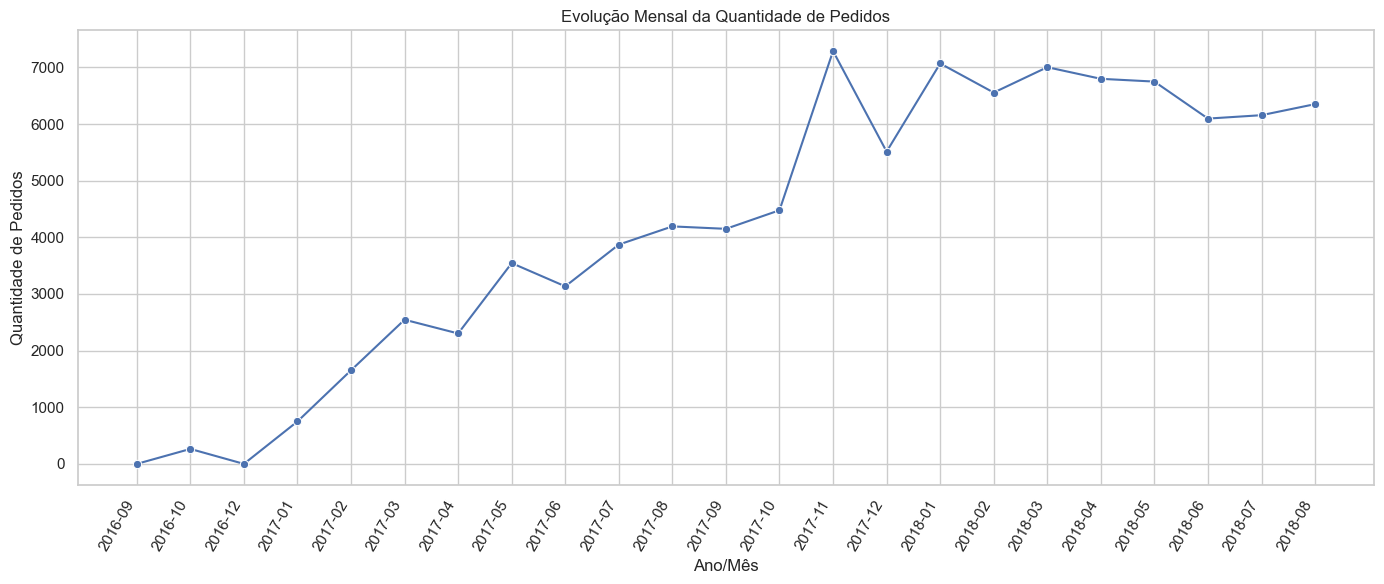

In [83]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=evolucao_mensal,
    x="ano_mes",
    y="pedidos",
    marker="o"
)

plt.title(
    "Evolução Mensal da Quantidade de Pedidos"
)

plt.xlabel("Ano/Mês")
plt.ylabel("Quantidade de Pedidos")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    PASTA_FIGURAS / "01_pedidos_mensais.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

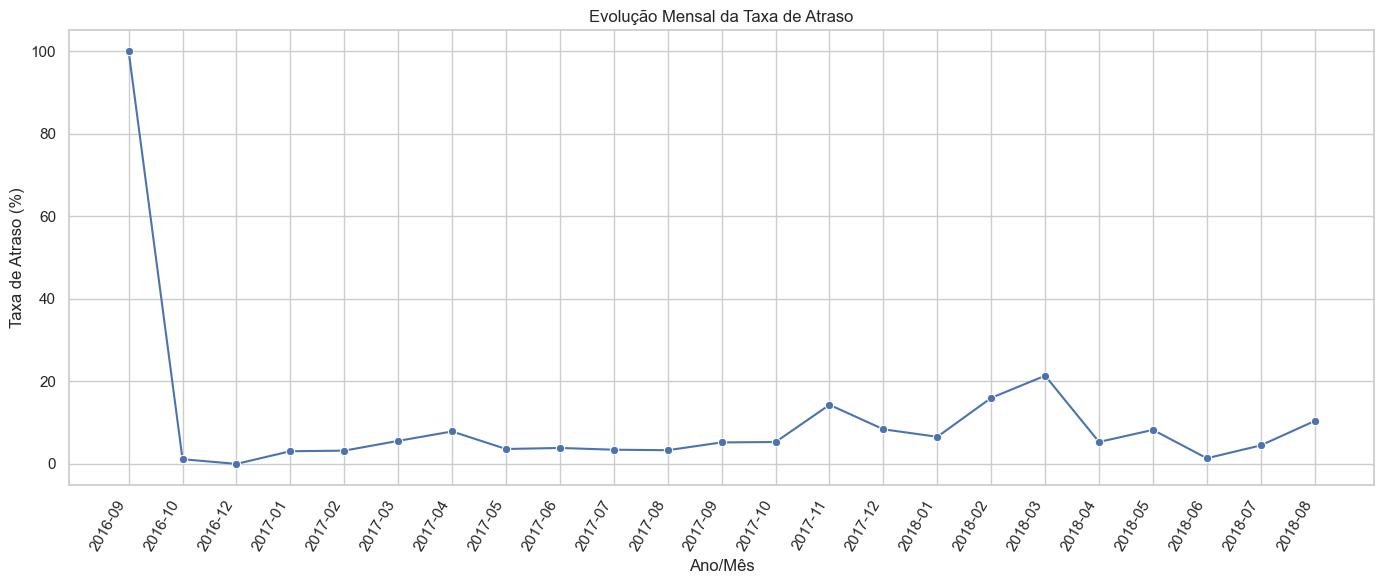

In [84]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=evolucao_mensal,
    x="ano_mes",
    y="taxa_atraso",
    marker="o"
)

plt.title(
    "Evolução Mensal da Taxa de Atraso"
)

plt.xlabel("Ano/Mês")
plt.ylabel("Taxa de Atraso (%)")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    PASTA_FIGURAS / "02_taxa_atraso_mensal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [85]:
pedidos_cliente = (
    modelo_df
    .groupby("customer_unique_id")
    ["order_id"]
    .nunique()
)

pedidos_cliente.describe()

count    93350.000000
mean         1.033423
std          0.209106
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         15.000000
Name: order_id, dtype: float64

In [86]:
clientes_recorrentes = (
    pedidos_cliente > 1
).sum()

percentual_recorrentes = (
    clientes_recorrentes
    / len(pedidos_cliente)
    * 100
)

print(
    f"Clientes únicos: "
    f"{len(pedidos_cliente):,}"
)

print(
    f"Clientes com mais de um pedido: "
    f"{clientes_recorrentes:,}"
)

print(
    f"Percentual de clientes recorrentes: "
    f"{percentual_recorrentes:.2f}%"
)

Clientes únicos: 93,350
Clientes com mais de um pedido: 2,801
Percentual de clientes recorrentes: 3.00%


In [87]:
atraso_estado = (
    modelo_df
    .groupby(
        "customer_state"
    )
    .agg(
        pedidos=("order_id", "count"),
        atrasos=("delivered_late", "sum"),
        taxa_atraso=("delivered_late", "mean")
    )
)

atraso_estado["taxa_atraso"] *= 100

In [88]:
atraso_estado_100 = (
    atraso_estado[
        atraso_estado["pedidos"] >= 100
    ]
    .sort_values(
        "taxa_atraso",
        ascending=False
    )
)

atraso_estado_100

,pedidos,atrasos,taxa_atraso
customer_state,,,
AL,397,95,23.929471
MA,717,141,19.665272
PI,476,76,15.966387
CE,1279,196,15.324472
SE,335,51,15.223881
BA,3256,457,14.035627
RJ,12350,1664,13.473684
TO,274,35,12.773723
PA,946,117,12.367865


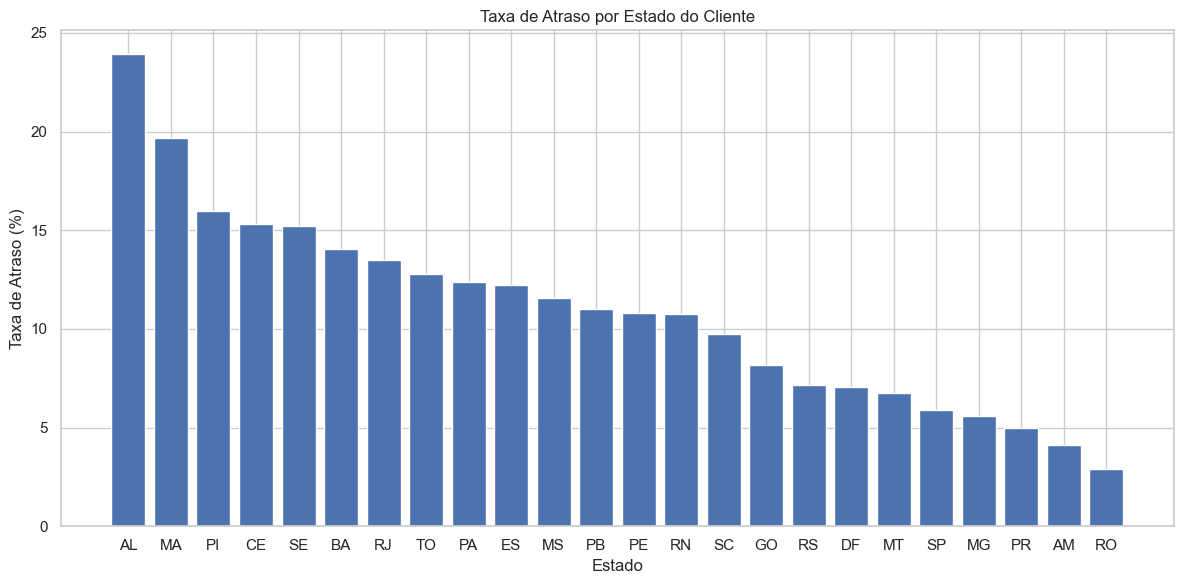

In [89]:
dados_estado_plot = atraso_estado_100.reset_index()

plt.figure(figsize=(12, 6))
plt.bar(
    dados_estado_plot["customer_state"],
    dados_estado_plot["taxa_atraso"]
)
plt.title("Taxa de Atraso por Estado do Cliente")
plt.xlabel("Estado")
plt.ylabel("Taxa de Atraso (%)")
plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "03_atraso_por_estado.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [90]:
atraso_categoria = (
    modelo_df
    .groupby(
        "categoria_principal"
    )
    .agg(
        pedidos=("order_id", "count"),
        atrasos=("delivered_late", "sum"),
        taxa_atraso=("delivered_late", "mean")
    )
)

atraso_categoria["taxa_atraso"] *= 100

In [91]:
atraso_categoria_100 = (
    atraso_categoria[
        atraso_categoria["pedidos"] >= 100
    ]
    .sort_values(
        "taxa_atraso",
        ascending=False
    )
)

atraso_categoria_100.head(15)

,pedidos,atrasos,taxa_atraso
categoria_principal,,,
audio,348,45,12.931034
fashion_underwear_beach,117,15,12.820513
home_confort,346,38,10.982659
books_technical,256,28,10.937500
food,436,44,10.091743
electronics,2509,247,9.844560
christmas_supplies,125,12,9.600000
construction_tools_lights,237,22,9.282700
office_furniture,1244,115,9.244373


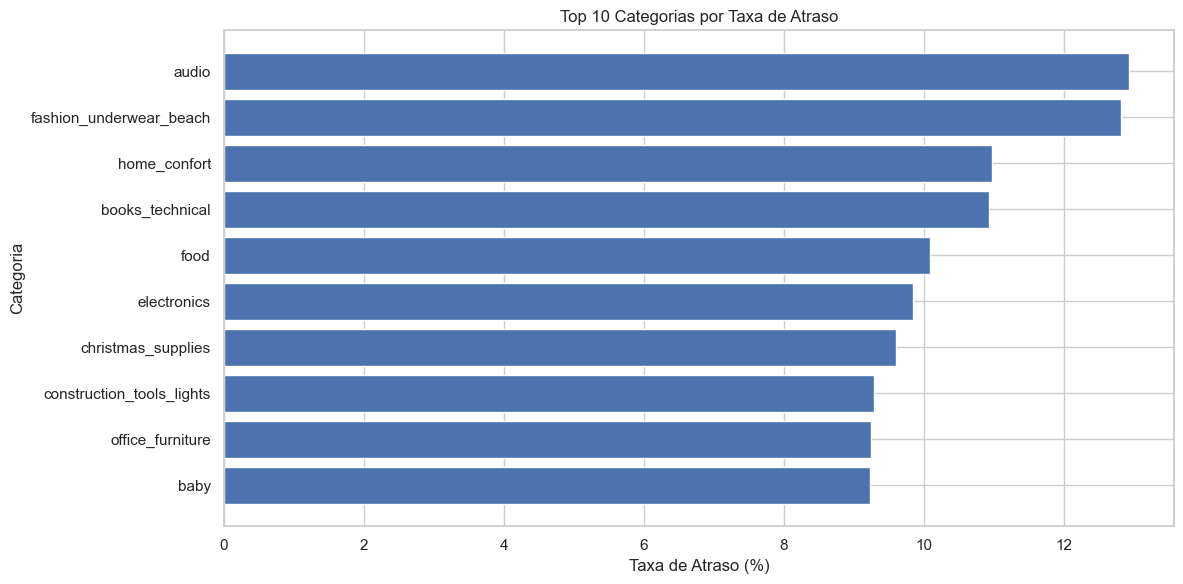

In [92]:
top10_categoria_atraso = (
    atraso_categoria_100
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))
plt.barh(
    top10_categoria_atraso["categoria_principal"],
    top10_categoria_atraso["taxa_atraso"]
)
plt.title("Top 10 Categorias por Taxa de Atraso")
plt.xlabel("Taxa de Atraso (%)")
plt.ylabel("Categoria")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "04_atraso_por_categoria.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [93]:
distancia_atraso = (
    modelo_df
    .groupby("delivered_late")
    ["distancia_media_km"]
    .agg(
        ["count", "mean", "median"]
    )
)

distancia_atraso

,count,mean,median
delivered_late,,,
0,88216,588.551349,426.686352
1,7776,738.822237,511.825201


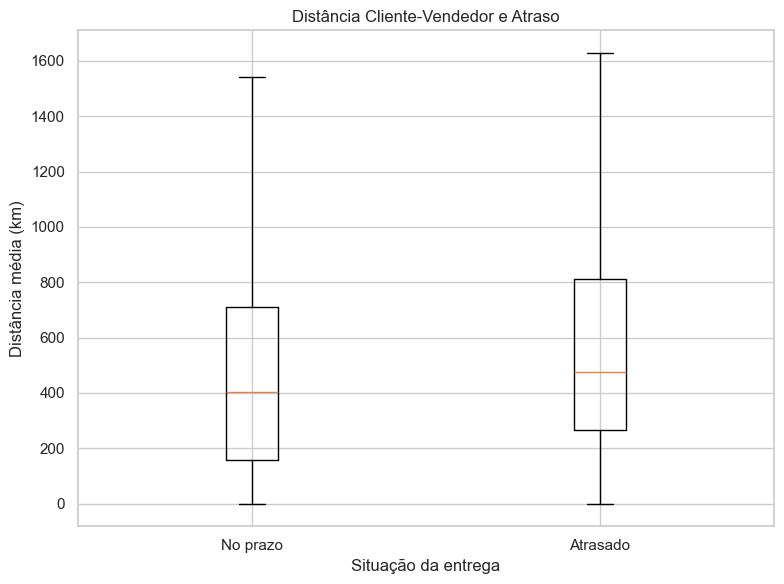

In [94]:
dados_distancia = modelo_df[
    modelo_df["distancia_media_km"].notna()
].copy()

limite_distancia = dados_distancia["distancia_media_km"].quantile(0.95)
dados_distancia_plot = dados_distancia[
    dados_distancia["distancia_media_km"] <= limite_distancia
]

grupo_prazo = dados_distancia_plot.loc[
    dados_distancia_plot["delivered_late"] == 0, "distancia_media_km"
]
grupo_atraso = dados_distancia_plot.loc[
    dados_distancia_plot["delivered_late"] == 1, "distancia_media_km"
]

plt.figure(figsize=(8, 6))
plt.boxplot(
    [grupo_prazo, grupo_atraso],
    **{PARAMETRO_ROTULOS_BOXPLOT: ["No prazo", "Atrasado"]},
    showfliers=False
)
plt.title("Distância Cliente-Vendedor e Atraso")
plt.xlabel("Situação da entrega")
plt.ylabel("Distância média (km)")
plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "05_distancia_atraso.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [95]:
peso_atraso = (
    modelo_df
    .groupby("delivered_late")
    ["peso_medio"]
    .agg(
        ["count", "mean", "median"]
    )
)

peso_atraso

,count,mean,median
delivered_late,,,
0,88628,2071.854114,688.0
1,7826,2397.431850,750.0


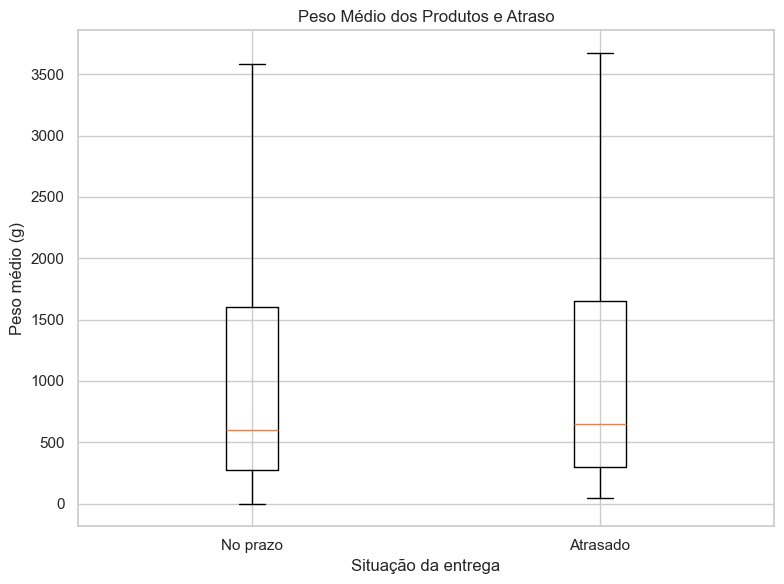

In [96]:
dados_peso = modelo_df[
    modelo_df["peso_medio"].notna()
].copy()

limite_peso = dados_peso["peso_medio"].quantile(0.95)
dados_peso_plot = dados_peso[
    dados_peso["peso_medio"] <= limite_peso
]

grupo_prazo_peso = dados_peso_plot.loc[
    dados_peso_plot["delivered_late"] == 0, "peso_medio"
]
grupo_atraso_peso = dados_peso_plot.loc[
    dados_peso_plot["delivered_late"] == 1, "peso_medio"
]

plt.figure(figsize=(8, 6))
plt.boxplot(
    [grupo_prazo_peso, grupo_atraso_peso],
    **{PARAMETRO_ROTULOS_BOXPLOT: ["No prazo", "Atrasado"]},
    showfliers=False
)
plt.title("Peso Médio dos Produtos e Atraso")
plt.xlabel("Situação da entrega")
plt.ylabel("Peso médio (g)")
plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "06_peso_atraso.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [97]:
avaliacao_atraso = (
    modelo_df
    .groupby(
        "delivered_late"
    )
    .agg(
        pedidos=("order_id", "count"),
        nota_media=("review_score", "mean")
    )
)

avaliacao_atraso

,pedidos,nota_media
delivered_late,,
0,88644,4.294292
1,7826,2.566506


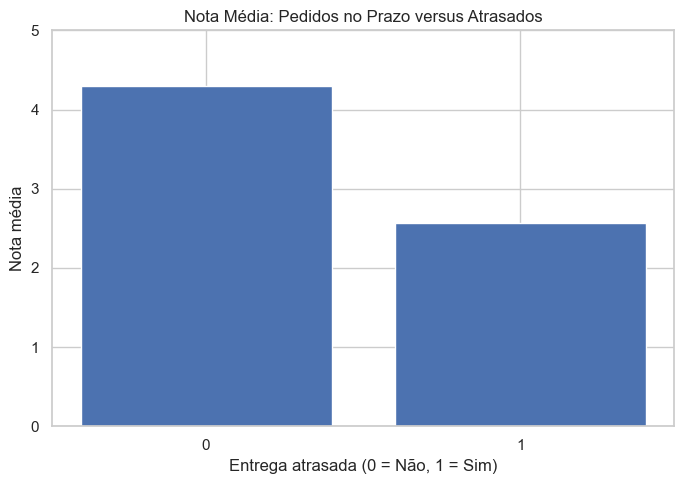

In [98]:
avaliacao_atraso_plot = avaliacao_atraso.reset_index()

plt.figure(figsize=(7, 5))
plt.bar(
    avaliacao_atraso_plot["delivered_late"].astype(str),
    avaliacao_atraso_plot["nota_media"]
)
plt.title("Nota Média: Pedidos no Prazo versus Atrasados")
plt.xlabel("Entrega atrasada (0 = Não, 1 = Sim)")
plt.ylabel("Nota média")
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "07_avaliacao_atraso.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### 7.1 Forma de pagamento e atraso

O enunciado do trabalho questiona explicitamente como a forma de pagamento se
relaciona com o prazo de entrega. A forma de pagamento nao atua diretamente
sobre o transporte, mas influencia o tempo ate a aprovacao do pedido: boleto,
por exemplo, so e confirmado apos a compensacao bancaria, o que consome parte
da folga do prazo prometido.

In [99]:
atraso_pagamento = (
    modelo_df
    .dropna(subset=["tipo_pagamento"])
    .groupby("tipo_pagamento")
    .agg(
        pedidos=("order_id", "count"),
        atrasos=("delivered_late", "sum"),
        taxa_atraso=("delivered_late", "mean"),
        parcelas_medias=("parcelas_maximas", "mean")
    )
)

atraso_pagamento["taxa_atraso"] *= 100

atraso_pagamento = atraso_pagamento.sort_values(
    "taxa_atraso",
    ascending=False
)

atraso_pagamento

,pedidos,atrasos,taxa_atraso,parcelas_medias
tipo_pagamento,,,,
boleto,19191,1704,8.879162,1.000938
debit_card,1483,118,7.956844,1.000000
credit_card,73934,5871,7.940866,3.512971
voucher,1861,132,7.092961,1.117141


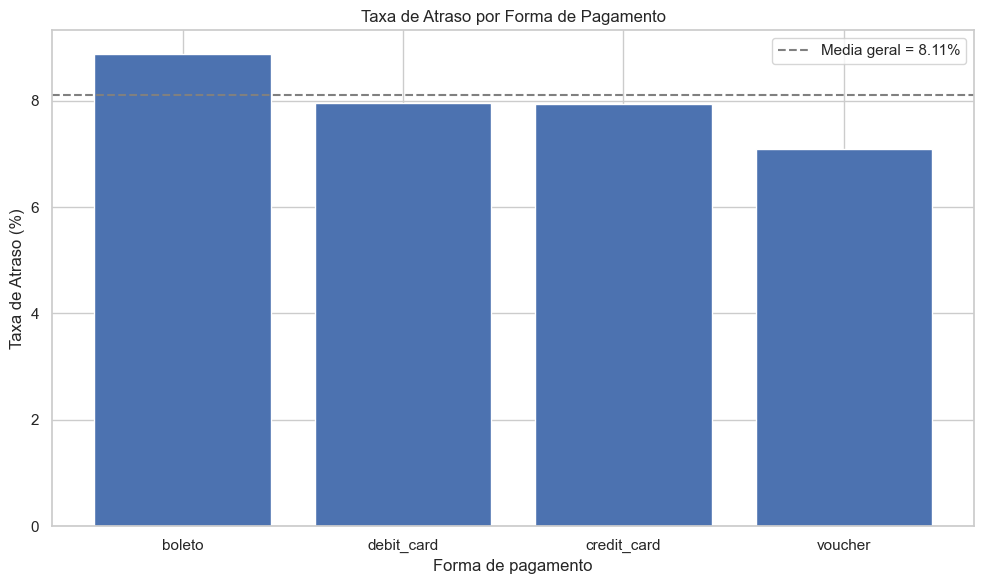

In [100]:
dados_pagamento_plot = atraso_pagamento.reset_index()

plt.figure(figsize=(10, 6))
plt.bar(
    dados_pagamento_plot["tipo_pagamento"],
    dados_pagamento_plot["taxa_atraso"]
)
plt.axhline(
    y=taxa_atraso,
    linestyle="--",
    color="gray",
    label=f"Media geral = {taxa_atraso:.2f}%"
)
plt.title("Taxa de Atraso por Forma de Pagamento")
plt.xlabel("Forma de pagamento")
plt.ylabel("Taxa de Atraso (%)")
plt.legend()
plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "08_atraso_por_pagamento.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 7.2 Sazonalidade da operacao

A serie mensal apresentada anteriormente mostra a evolucao ao longo do periodo,
mas nao isola o efeito do calendario. Nesta etapa a sazonalidade e analisada por
mes do ano e por dia da semana da compra, variaveis que tambem alimentam o
modelo preditivo. A tabela cruzada e construida com `pivot_table`, resumindo a
taxa de atraso por ano e mes.

In [101]:
modelo_df["ano_compra"] = (
    modelo_df["order_purchase_timestamp"].dt.year
)

# pivot_table resume a taxa de atraso cruzando ano e mes da compra.
sazonalidade_pivot = pd.pivot_table(
    modelo_df,
    index="mes_compra",
    columns="ano_compra",
    values="delivered_late",
    aggfunc="mean"
) * 100

sazonalidade_pivot.round(2)

ano_compra,2016,2017,2018
mes_compra,,,
1,NaN,3.07,6.56
2,NaN,3.21,15.99
3,NaN,5.58,21.36
4,NaN,7.86,5.31
5,NaN,3.61,8.24
6,NaN,3.86,1.36
7,NaN,3.43,4.48
8,NaN,3.32,10.39
9,100.00,5.20,NaN


In [102]:
atraso_mes = (
    modelo_df
    .groupby("mes_compra", as_index=False)
    .agg(
        pedidos=("order_id", "count"),
        taxa_atraso=("delivered_late", "mean")
    )
)

atraso_mes["taxa_atraso"] *= 100

atraso_dia_semana = (
    modelo_df
    .groupby("dia_semana_compra", as_index=False)
    .agg(
        pedidos=("order_id", "count"),
        taxa_atraso=("delivered_late", "mean")
    )
)

atraso_dia_semana["taxa_atraso"] *= 100

NOMES_DIAS = [
    "Segunda", "Terca", "Quarta", "Quinta",
    "Sexta", "Sabado", "Domingo"
]

atraso_dia_semana["dia_nome"] = (
    atraso_dia_semana["dia_semana_compra"].map(
        dict(enumerate(NOMES_DIAS))
    )
)

display(atraso_mes)
display(atraso_dia_semana)

,mes_compra,pedidos,taxa_atraso
0,1,7819,6.228418
1,2,8208,13.413743
2,3,9549,17.153629
3,4,9101,5.955390
4,5,10294,6.644647
5,6,9231,2.209945
6,7,10028,4.078580
7,8,10544,7.577769
8,9,4151,5.227656
9,10,4743,5.060089


,dia_semana_compra,pedidos,taxa_atraso,dia_nome
0,0,15701,9.050379,Segunda
1,1,15502,8.489227,Terca
2,2,15074,7.801513,Quarta
3,3,14322,7.568775,Quinta
4,4,13684,8.447822,Sexta
5,5,10555,7.598295,Sabado
6,6,11632,7.487964,Domingo


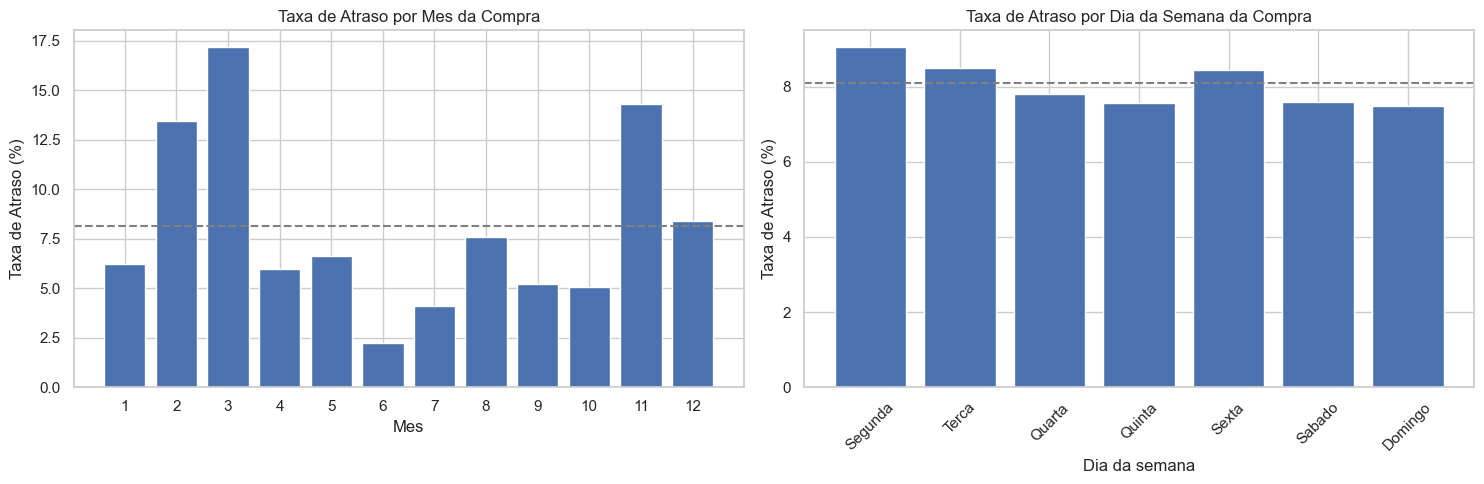

In [103]:
figura, eixos = plt.subplots(1, 2, figsize=(15, 5))

eixos[0].bar(
    atraso_mes["mes_compra"],
    atraso_mes["taxa_atraso"]
)
eixos[0].axhline(y=taxa_atraso, linestyle="--", color="gray")
eixos[0].set_title("Taxa de Atraso por Mes da Compra")
eixos[0].set_xlabel("Mes")
eixos[0].set_ylabel("Taxa de Atraso (%)")
eixos[0].set_xticks(range(1, 13))

eixos[1].bar(
    atraso_dia_semana["dia_nome"],
    atraso_dia_semana["taxa_atraso"]
)
eixos[1].axhline(y=taxa_atraso, linestyle="--", color="gray")
eixos[1].set_title("Taxa de Atraso por Dia da Semana da Compra")
eixos[1].set_xlabel("Dia da semana")
eixos[1].set_ylabel("Taxa de Atraso (%)")
eixos[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "09_sazonalidade_atraso.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 7.3 Avaliacao dos vendedores e atraso

O enunciado tambem solicita a analise da relacao entre a avaliacao dos
vendedores e o prazo de entrega. A nota media de cada vendedor e reconstruida a
partir das avaliacoes dos pedidos em que ele participou e depois atribuida ao
pedido.

Essa variavel e derivada de informacao posterior a entrega e, por isso, e
utilizada **exclusivamente na analise descritiva**, permanecendo fora do
conjunto de preditores para evitar vazamento de dados.

In [104]:
# Nota media historica por vendedor, reconstruida a partir das avaliacoes
# dos pedidos em que o vendedor participou.
pares_pedido_vendedor = (
    itens[["order_id", "seller_id"]]
    .drop_duplicates()
)

notas_vendedor = (
    pares_pedido_vendedor
    .merge(avaliacoes_pedido, on="order_id", how="left")
    .groupby("seller_id", as_index=False)
    .agg(
        pedidos_vendedor=("order_id", "nunique"),
        nota_media_vendedor=("review_score", "mean")
    )
)

print("Vendedores avaliados:", len(notas_vendedor))
display(notas_vendedor["nota_media_vendedor"].describe())

Vendedores avaliados: 3095


count    3090.000000
mean        3.998437
std         0.955809
min         1.000000
25%         3.777778
50%         4.184699
75%         4.600000
max         5.000000
Name: nota_media_vendedor, dtype: float64

In [105]:
# Cada pedido recebe a media das notas dos vendedores que o atenderam.
nota_vendedor_pedido = (
    pares_pedido_vendedor
    .merge(
        notas_vendedor[["seller_id", "nota_media_vendedor"]],
        on="seller_id",
        how="left"
    )
    .groupby("order_id", as_index=False)
    .agg(nota_media_vendedor=("nota_media_vendedor", "mean"))
)

modelo_df = modelo_df.merge(
    nota_vendedor_pedido,
    on="order_id",
    how="left",
    validate="one_to_one"
)

print(
    "Pedidos sem nota de vendedor:",
    modelo_df["nota_media_vendedor"].isna().sum()
)

Pedidos sem nota de vendedor: 3


In [106]:
faixas = [0, 3.0, 3.5, 4.0, 4.5, 5.01]

rotulos = [
    "Ate 3,0",
    "3,0 a 3,5",
    "3,5 a 4,0",
    "4,0 a 4,5",
    "Acima de 4,5"
]

modelo_df["faixa_nota_vendedor"] = pd.cut(
    modelo_df["nota_media_vendedor"],
    bins=faixas,
    labels=rotulos,
    right=False
)

atraso_nota_vendedor = (
    modelo_df
    .dropna(subset=["faixa_nota_vendedor"])
    .groupby("faixa_nota_vendedor", observed=True)
    .agg(
        pedidos=("order_id", "count"),
        taxa_atraso=("delivered_late", "mean")
    )
)

atraso_nota_vendedor["taxa_atraso"] *= 100

atraso_nota_vendedor

,pedidos,taxa_atraso
faixa_nota_vendedor,,
"Ate 3,0",857,22.403734
"3,0 a 3,5",3569,14.906136
"3,5 a 4,0",26130,10.057405
"4,0 a 4,5",58926,7.132675
"Acima de 4,5",6985,3.836793


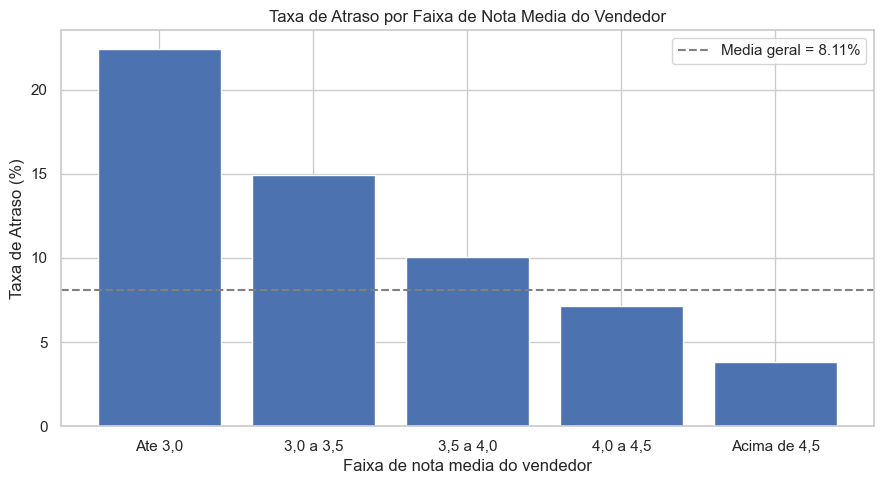

In [107]:
dados_nota_plot = atraso_nota_vendedor.reset_index()

plt.figure(figsize=(9, 5))
plt.bar(
    dados_nota_plot["faixa_nota_vendedor"].astype(str),
    dados_nota_plot["taxa_atraso"]
)
plt.axhline(
    y=taxa_atraso,
    linestyle="--",
    color="gray",
    label=f"Media geral = {taxa_atraso:.2f}%"
)
plt.title("Taxa de Atraso por Faixa de Nota Media do Vendedor")
plt.xlabel("Faixa de nota media do vendedor")
plt.ylabel("Taxa de Atraso (%)")
plt.legend()
plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "10_atraso_por_nota_vendedor.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [108]:
print("RESUMO DA EDA")
print("=" * 60)

print(
    f"Pedidos analisados: "
    f"{total_pedidos:,}"
)

print(
    f"Taxa geral de atraso: "
    f"{taxa_atraso:.2f}%"
)

print(
    f"Estado com maior taxa de atraso: "
    f"{atraso_estado_100.index[0]} "
    f"({atraso_estado_100.iloc[0]['taxa_atraso']:.2f}%)"
)

print(
    f"Categoria com maior taxa de atraso: "
    f"{atraso_categoria_100.index[0]} "
    f"({atraso_categoria_100.iloc[0]['taxa_atraso']:.2f}%)"
)

print(
    f"Tempo médio de entrega: "
    f"{tempo_medio_entrega:.2f} dias"
)

print(
    f"Nota média geral: "
    f"{nota_media:.2f}"
)

RESUMO DA EDA
Pedidos analisados: 96,470
Taxa geral de atraso: 8.11%
Estado com maior taxa de atraso: AL (23.93%)
Categoria com maior taxa de atraso: audio (12.93%)
Tempo médio de entrega: 12.56 dias
Nota média geral: 4.16


## 8. Modelagem Preditiva de Atrasos

O problema é tratado como uma classificação binária.

A variável-alvo `delivered_late` assume:

- 0: pedido entregue no prazo;
- 1: pedido entregue após a data estimada.

Para evitar vazamento de dados, somente informações disponíveis
até o momento da compra são utilizadas como variáveis preditoras.

São comparados dois algoritmos:

1. Regressão Logística;
2. Random Forest.

A avaliação utiliza divisão temporal dos dados, simulando a previsão
de pedidos futuros.

In [109]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    TimeSeriesSplit,
    cross_validate
)

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

from sklearn.base import clone

import joblib

# RANDOM_STATE ja foi definido na secao 2 (Configuracao).

print("Bibliotecas de Machine Learning carregadas.")

Bibliotecas de Machine Learning carregadas.


In [110]:
modelo_df["log_valor_pagamento"] = np.log1p(
    modelo_df["valor_pagamento"]
)

In [111]:
modelo_df = modelo_df.replace(
    [np.inf, -np.inf],
    np.nan
)

### 8.1 Seleção dos atributos

As variáveis utilizadas na previsão representam informações temporais,
comerciais, logísticas, geográficas e de pagamento disponíveis antes
da entrega do pedido.

Variáveis posteriores à entrega são excluídas da modelagem.

In [112]:
variaveis_numericas = [
    "mes_compra",
    "dia_semana_compra",
    "hora_compra",
    "prazo_prometido_dias",
    "quantidade_itens",
    "quantidade_vendedores",
    "quantidade_categorias",
    "log_preco",
    "log_frete",
    "frete_preco",
    "log_peso",
    "log_volume",
    "log_distancia",
    "log_valor_pagamento",
    "quantidade_pagamentos",
    "parcelas_maximas",
    "mesmo_estado"
]

In [113]:
variaveis_categoricas = [
    "customer_state",
    "estado_vendedor",
    "categoria_principal",
    "tipo_pagamento"
]

In [114]:
features = (
    variaveis_numericas
    + variaveis_categoricas
)

print("Quantidade de variáveis preditoras:", len(features))

Quantidade de variáveis preditoras: 21


In [115]:
variaveis_faltantes = [
    coluna
    for coluna in features
    if coluna not in modelo_df.columns
]

if variaveis_faltantes:
    print("Variáveis faltantes:")
    print(variaveis_faltantes)
else:
    print("Todas as variáveis foram encontradas.")

Todas as variáveis foram encontradas.


In [116]:
variaveis_proibidas = [
    "review_score",
    "nota_media_vendedor",
    "faixa_nota_vendedor",
    "order_delivered_customer_date",
    "order_delivered_carrier_date",
    "tempo_entrega_dias",
    "dias_atraso"
]

vazamento = [
    coluna
    for coluna in variaveis_proibidas
    if coluna in features
]

print("Variáveis com possível vazamento:", vazamento)

assert not vazamento, (
    "Há variáveis posteriores à entrega entre os preditores."
)

Variáveis com possível vazamento: []


In [117]:
modelo_ordenado = (
    modelo_df
    .sort_values(
        "order_purchase_timestamp"
    )
    .reset_index(drop=True)
)

print(
    modelo_ordenado[
        "order_purchase_timestamp"
    ].min()
)

print(
    modelo_ordenado[
        "order_purchase_timestamp"
    ].max()
)

2016-09-15 12:16:38
2018-08-29 15:00:37


In [118]:
X = modelo_ordenado[features].copy()
y = modelo_ordenado["delivered_late"].copy()

assert len(X) == len(y), "X e y precisam ter a mesma quantidade de linhas."
assert y.notna().all(), "A variável-alvo y contém valores ausentes."

print("Variáveis preditoras X e variável-alvo y criadas com sucesso.")


Variáveis preditoras X e variável-alvo y criadas com sucesso.


In [119]:
# Verificação defensiva para permitir a execução desta etapa isoladamente.
if "X" not in globals() or "y" not in globals():
    X = modelo_ordenado[features].copy()
    y = modelo_ordenado["delivered_late"].copy()

print("X:", X.shape)
print("y:", y.shape)

print("\nDistribuição do alvo:")
print(y.value_counts())

print("\nPercentual:")
print(y.value_counts(normalize=True) * 100)


X: (96470, 21)
y: (96470,)

Distribuição do alvo:
delivered_late
0    88644
1     7826
Name: count, dtype: int64

Percentual:
delivered_late
0    91.887633
1     8.112367
Name: proportion, dtype: float64


In [120]:
print(
    "Etapa validada: X e y possuem o mesmo número de registros."
    if len(X) == len(y)
    else "Atenção: revise X e y."
)


Etapa validada: X e y possuem o mesmo número de registros.


#### Divisao cronologica

A separacao entre treino e teste segue a ordem temporal das compras: os 80% mais
antigos formam o treino e os 20% mais recentes formam o teste. Esse desenho
reproduz a situacao real de prever pedidos futuros e evita o otimismo de uma
divisao aleatoria.

In [121]:
corte = int(
    len(modelo_ordenado) * 0.80
)

X_train = X.iloc[:corte].copy()
X_test = X.iloc[corte:].copy()

y_train = y.iloc[:corte].copy()
y_test = y.iloc[corte:].copy()

In [122]:
print("TREINO")
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nTESTE")
print("X:", X_test.shape)
print("y:", y_test.shape)

TREINO
X: (77176, 21)
y: (77176,)

TESTE
X: (19294, 21)
y: (19294,)


In [123]:
print("PERÍODO DE TREINO")
print(
    modelo_ordenado.loc[
        :corte - 1,
        "order_purchase_timestamp"
    ].min()
)

print(
    modelo_ordenado.loc[
        :corte - 1,
        "order_purchase_timestamp"
    ].max()
)

print("\nPERÍODO DE TESTE")
print(
    modelo_ordenado.loc[
        corte:,
        "order_purchase_timestamp"
    ].min()
)

print(
    modelo_ordenado.loc[
        corte:,
        "order_purchase_timestamp"
    ].max()
)

PERÍODO DE TREINO
2016-09-15 12:16:38
2018-05-26 18:16:57

PERÍODO DE TESTE
2018-05-26 18:18:03
2018-08-29 15:00:37


In [124]:
print(
    f"Taxa de atraso no treino: "
    f"{y_train.mean() * 100:.2f}%"
)

print(
    f"Taxa de atraso no teste: "
    f"{y_test.mean() * 100:.2f}%"
)

Taxa de atraso no treino: 8.82%
Taxa de atraso no teste: 5.29%


### 8.2 Pipeline de pré-processamento

Valores numéricos ausentes são imputados pela mediana calculada
exclusivamente no conjunto de treino.

Em seguida é utilizado RobustScaler, que possui menor sensibilidade
a valores extremos.

In [125]:
pipeline_numerico = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            RobustScaler()
        )
    ]
)

In [126]:
pipeline_categorico = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [127]:
preprocessador = ColumnTransformer(
    transformers=[
        (
            "num",
            pipeline_numerico,
            variaveis_numericas
        ),
        (
            "cat",
            pipeline_categorico,
            variaveis_categoricas
        )
    ]
)

print("Pré-processador criado.")

Pré-processador criado.


### 8.3 Regressão Logística

A Regressão Logística é utilizada como modelo de referência
por sua interpretabilidade e capacidade de estimar probabilidades
para uma classificação binária.

In [128]:
regressao_logistica = Pipeline(
    steps=[
        (
            "preprocessamento",
            preprocessador
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

### 8.4 Random Forest

A Random Forest combina várias árvores de decisão e permite capturar
relações não lineares e interações entre os atributos.

In [129]:
random_forest = Pipeline(
    steps=[
        (
            "preprocessamento",
            preprocessador
        ),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=150,
                min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

#### Comparacao dos algoritmos

Os dois algoritmos sao avaliados com `TimeSeriesSplit`, que respeita a ordem
temporal em cada particao. A selecao usa a PR-AUC, mais informativa que a
acuracia quando a classe positiva e minoritaria.

In [130]:
tscv = TimeSeriesSplit(
    n_splits=5
)

print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [131]:
modelos = {
    "Regressão Logística":
        regressao_logistica,
        
    "Random Forest":
        random_forest
}

In [132]:
resultados_cv = []

for nome, modelo in modelos.items():
    
    print(
        f"Avaliando: {nome}"
    )
    
    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=tscv,
        scoring={
            "roc_auc":
                "roc_auc",
            "pr_auc":
                "average_precision",
            "recall":
                "recall",
            "precision":
                "precision",
            "f1":
                "f1"
        },
        n_jobs=1
    )
    
    resultados_cv.append({
        "modelo": nome,
        
        "ROC_AUC":
            scores[
                "test_roc_auc"
            ].mean(),
        
        "PR_AUC":
            scores[
                "test_pr_auc"
            ].mean(),
        
        "Recall":
            scores[
                "test_recall"
            ].mean(),
        
        "Precision":
            scores[
                "test_precision"
            ].mean(),
        
        "F1":
            scores[
                "test_f1"
            ].mean()
    })

print("Validação concluída.")

Avaliando: Regressão Logística
Avaliando: Random Forest
Validação concluída.


In [133]:
resultados_cv = pd.DataFrame(
    resultados_cv
)

resultados_cv

,modelo,ROC_AUC,PR_AUC,Recall,Precision,F1
0,Regressão Logística,0.667234,0.181111,0.485666,0.166072,0.228804
1,Random Forest,0.630731,0.161414,0.014577,0.388831,0.025133


In [134]:
resultados_cv = (
    resultados_cv
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

resultados_cv

,modelo,ROC_AUC,PR_AUC,Recall,Precision,F1
0,Regressão Logística,0.667234,0.181111,0.485666,0.166072,0.228804
1,Random Forest,0.630731,0.161414,0.014577,0.388831,0.025133


In [135]:
melhor_nome = (
    resultados_cv
    .iloc[0]["modelo"]
)

melhor_modelo = (
    modelos[melhor_nome]
)

print(
    "Melhor modelo pela PR-AUC:"
)

print(melhor_nome)

Melhor modelo pela PR-AUC:
Regressão Logística


### 8.5 Avaliação Final e Escolha do Limiar

Após a seleção do algoritmo pela PR-AUC na validação temporal, o limiar de decisão
é escolhido exclusivamente nos dados de treino/validação pela métrica F2, que atribui
maior peso ao Recall. O conjunto de teste permanece isolado até a avaliação final.


In [136]:
y_validacao = []
prob_validacao = []

for indice_treino, indice_validacao in tscv.split(X_train):
    
    modelo_fold = clone(melhor_modelo)
    
    modelo_fold.fit(
        X_train.iloc[indice_treino],
        y_train.iloc[indice_treino]
    )
    
    probabilidades = modelo_fold.predict_proba(
        X_train.iloc[indice_validacao]
    )[:, 1]
    
    prob_validacao.extend(probabilidades)
    
    y_validacao.extend(
        y_train.iloc[indice_validacao].values
    )

print("Previsões de validação concluídas.")

Previsões de validação concluídas.


In [137]:
y_validacao = np.array(y_validacao)
prob_validacao = np.array(prob_validacao)

print("Observações de validação:", len(y_validacao))
print("Probabilidades geradas:", len(prob_validacao))

Observações de validação: 64310
Probabilidades geradas: 64310


In [138]:
precisao_curve, recall_curve, thresholds = (
    precision_recall_curve(
        y_validacao,
        prob_validacao
    )
)

In [139]:
beta = 2

f2_scores = (
    (1 + beta ** 2)
    * precisao_curve[:-1]
    * recall_curve[:-1]
    /
    (
        beta ** 2 * precisao_curve[:-1]
        + recall_curve[:-1]
        + 1e-10
    )
)

In [140]:
indice_melhor = np.argmax(f2_scores)

melhor_threshold = thresholds[indice_melhor]
melhor_f2_validacao = f2_scores[indice_melhor]

print(f"Threshold escolhido: {melhor_threshold:.3f}")
print(f"Melhor F2 na validação: {melhor_f2_validacao:.3f}")

Threshold escolhido: 0.335
Melhor F2 na validação: 0.378


In [141]:
melhor_modelo.fit(
    X_train,
    y_train
)

print(
    f"Modelo final treinado: {melhor_nome}"
)

Modelo final treinado: Regressão Logística


In [142]:
prob_teste = melhor_modelo.predict_proba(
    X_test
)[:, 1]

In [143]:
pred_teste = (
    prob_teste >= melhor_threshold
).astype(int)

In [144]:
print("Probabilidades:", len(prob_teste))
print("Previsões:", len(pred_teste))
print("Observações reais:", len(y_test))

Probabilidades: 19294
Previsões: 19294
Observações reais: 19294


In [145]:
precision_final = precision_score(
    y_test,
    pred_teste
)

recall_final = recall_score(
    y_test,
    pred_teste
)

f1_final = f1_score(
    y_test,
    pred_teste
)

f2_final = fbeta_score(
    y_test,
    pred_teste,
    beta=2
)

roc_auc_final = roc_auc_score(
    y_test,
    prob_teste
)

pr_auc_final = average_precision_score(
    y_test,
    prob_teste
)

In [146]:
print("RESULTADOS FINAIS NO TESTE")
print("=" * 50)

print(f"Modelo: {melhor_nome}")
print(f"Threshold: {melhor_threshold:.3f}")
print(f"Precision: {precision_final:.3f}")
print(f"Recall: {recall_final:.3f}")
print(f"F1: {f1_final:.3f}")
print(f"F2: {f2_final:.3f}")
print(f"ROC-AUC: {roc_auc_final:.3f}")
print(f"PR-AUC: {pr_auc_final:.3f}")

RESULTADOS FINAIS NO TESTE
Modelo: Regressão Logística
Threshold: 0.335
Precision: 0.068
Recall: 0.955
F1: 0.127
F2: 0.265
ROC-AUC: 0.685
PR-AUC: 0.104


In [147]:
baseline_pr_auc = y_test.mean()

print(
    f"Baseline PR-AUC: "
    f"{baseline_pr_auc:.3f}"
)

print(
    f"PR-AUC do modelo: "
    f"{pr_auc_final:.3f}"
)

Baseline PR-AUC: 0.053
PR-AUC do modelo: 0.104


In [148]:
print(
    classification_report(
        y_test,
        pred_teste,
        digits=3
    )
)

              precision    recall  f1-score   support

           0      0.991     0.269     0.424     18273
           1      0.068     0.955     0.127      1021

    accuracy                          0.306     19294
   macro avg      0.529     0.612     0.275     19294
weighted avg      0.942     0.306     0.408     19294



In [149]:
matriz = confusion_matrix(
    y_test,
    pred_teste
)

matriz

array([[ 4922, 13351],
       [   46,   975]])

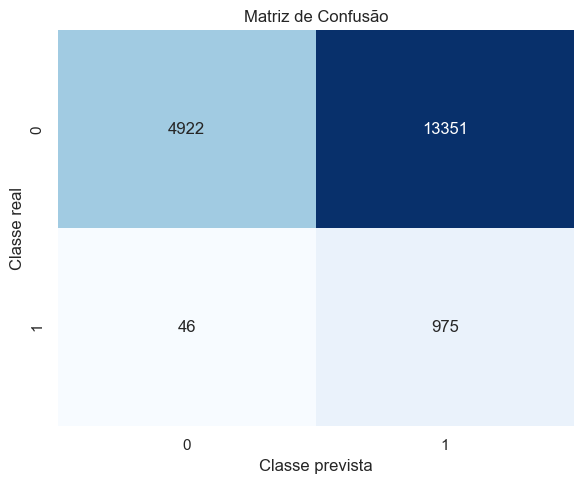

In [150]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Matriz de Confusão")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.tight_layout()

plt.savefig(
    PASTA_FIGURAS / "11_matriz_confusao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

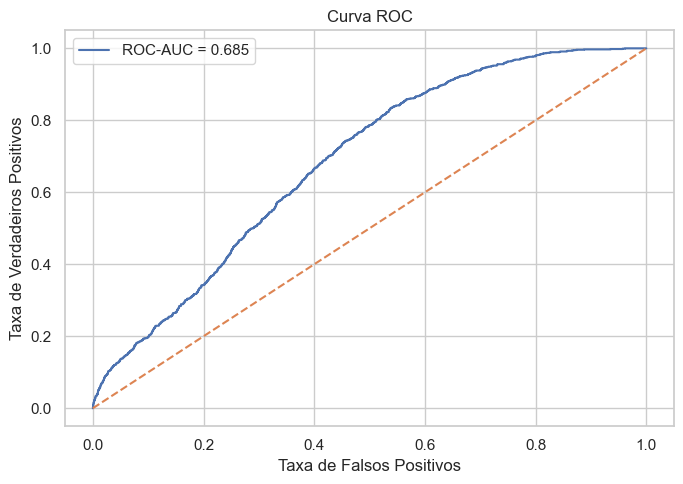

In [151]:
fpr, tpr, _ = roc_curve(
    y_test,
    prob_teste
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc_final:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC")

plt.legend()
plt.tight_layout()

plt.savefig(
    PASTA_FIGURAS / "12_curva_roc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [152]:
precision_pr, recall_pr, _ = (
    precision_recall_curve(
        y_test,
        prob_teste
    )
)

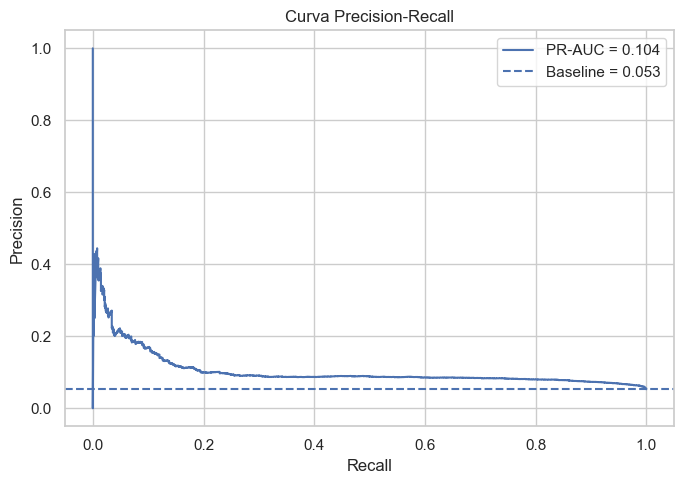

In [153]:
plt.figure(figsize=(7, 5))

plt.plot(
    recall_pr,
    precision_pr,
    label=f"PR-AUC = {pr_auc_final:.3f}"
)

plt.axhline(
    y=baseline_pr_auc,
    linestyle="--",
    label=f"Baseline = {baseline_pr_auc:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")

plt.legend()
plt.tight_layout()

plt.savefig(
    PASTA_FIGURAS
    / "13_curva_precision_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretação da Avaliação

A classe de atrasos é minoritária e apresenta mudança temporal relevante:
a taxa de atraso é de aproximadamente **8,82% no treino** e **5,29% no teste**.

A Regressão Logística foi selecionada na validação temporal. No teste, apresentou
**PR-AUC de 0,104**, superior ao baseline de aproximadamente **0,053**, e
**ROC-AUC de 0,685**. Com limiar de aproximadamente **0,333**, o modelo alcançou
**Recall de 0,956**, identificando a maior parte dos pedidos que efetivamente atrasaram.

Em contrapartida, a **Precision de 0,068** indica grande quantidade de falsos positivos.
Esse comportamento decorre da estratégia de priorizar Recall/F2: reduzir falsos negativos
exige aceitar mais alertas preventivos. A matriz de confusão confirma esse trade-off.

A PR-AUC média da validação temporal foi superior à observada no teste, o que, junto
à mudança na prevalência de atrasos, sugere possível mudança de distribuição ao longo
do tempo. Em aplicação operacional, o desempenho deve ser monitorado e o limiar deve
ser calibrado conforme o custo de falsos positivos e falsos negativos.


In [154]:
from IPython.display import display, Markdown

preprocessador_final = (
    melhor_modelo
    .named_steps["preprocessamento"]
)

nomes_features = (
    preprocessador_final
    .get_feature_names_out()
)

print(
    "Quantidade de atributos "
    "apos transformacao:",
    len(nomes_features)
)

Quantidade de atributos apos transformacao: 142


In [155]:
# A extracao da importancia depende do algoritmo vencedor, mas o
# resultado e sempre consolidado em importancia_df com a coluna
# impacto_absoluto, o que garante que a tabela e o grafico da etapa
# seguinte sejam produzidos em qualquer um dos dois cenarios.
if melhor_nome == "Random Forest":

    valores = (
        melhor_modelo
        .named_steps["modelo"]
        .feature_importances_
    )

    importancia_df = pd.DataFrame({
        "variavel": nomes_features,
        "importancia": valores,
        "impacto_absoluto": np.abs(valores)
    })

    tipo_medida = "Importancia media (Gini)"

else:

    coeficientes = (
        melhor_modelo
        .named_steps["modelo"]
        .coef_[0]
    )

    importancia_df = pd.DataFrame({
        "variavel": nomes_features,
        "coeficiente": coeficientes,
        "impacto_absoluto": np.abs(coeficientes)
    })

    tipo_medida = "Coeficiente da Regressao Logistica"

importancia_df = (
    importancia_df
    .sort_values("impacto_absoluto", ascending=False)
    .reset_index(drop=True)
)

print("Medida de importancia utilizada:", tipo_medida)

display(importancia_df.head(20))

Medida de importancia utilizada: Coeficiente da Regressao Logistica


,variavel,coeficiente,impacto_absoluto
0,cat__estado_vendedor_MA,1.612425,1.612425
1,num__quantidade_vendedores,-1.569272,1.569272
2,cat__customer_state_RR,1.550793,1.550793
3,cat__customer_state_AL,1.137591,1.137591
4,cat__categoria_principal_home_comfort_2,0.906298,0.906298
5,cat__estado_vendedor_AM,0.901297,0.901297
6,num__prazo_prometido_dias,-0.894519,0.894519
7,cat__customer_state_RO,-0.845340,0.845340
8,cat__customer_state_PR,-0.830717,0.830717
9,cat__customer_state_MG,-0.772703,0.772703


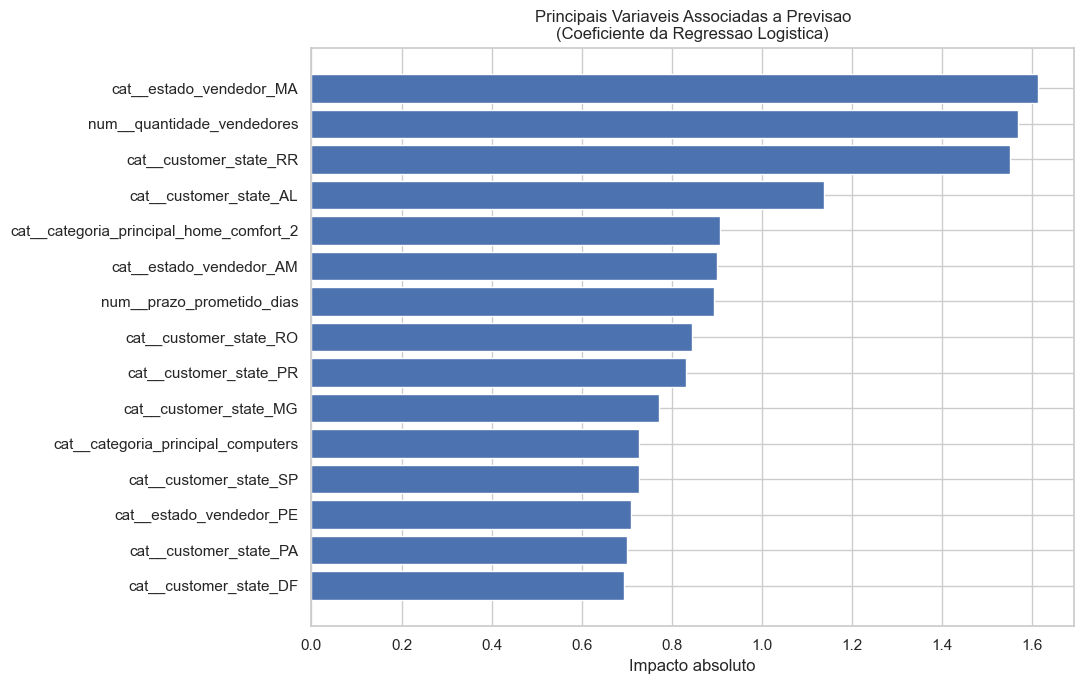

In [156]:
top_importancias = (
    importancia_df
    .head(15)
    .sort_values("impacto_absoluto")
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_importancias["variavel"],
    top_importancias["impacto_absoluto"]
)

plt.title(
    f"Principais Variaveis Associadas a Previsao\n({tipo_medida})"
)

plt.xlabel("Impacto absoluto")

plt.tight_layout()

plt.savefig(
    PASTA_FIGURAS
    / "14_importancia_variaveis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [157]:
# Na Regressao Logistica o sinal do coeficiente indica a direcao da
# associacao, o que permite separar os fatores que aumentam dos que
# reduzem a probabilidade estimada de atraso.
if "coeficiente" in importancia_df.columns:

    print("VARIAVEIS QUE MAIS AUMENTAM O RISCO DE ATRASO")
    display(
        importancia_df
        .sort_values("coeficiente", ascending=False)
        .head(10)
        [["variavel", "coeficiente"]]
    )

    print("VARIAVEIS QUE MAIS REDUZEM O RISCO DE ATRASO")
    display(
        importancia_df
        .sort_values("coeficiente")
        .head(10)
        [["variavel", "coeficiente"]]
    )

VARIAVEIS QUE MAIS AUMENTAM O RISCO DE ATRASO


,variavel,coeficiente
0,cat__estado_vendedor_MA,1.612425
2,cat__customer_state_RR,1.550793
3,cat__customer_state_AL,1.137591
4,cat__categoria_principal_home_comfort_2,0.906298
5,cat__estado_vendedor_AM,0.901297
13,cat__customer_state_PA,0.700219
16,cat__categoria_principal_audio,0.645701
17,cat__categoria_principal_christmas_supplies,0.639618
18,cat__estado_vendedor_RN,0.595267
19,cat__categoria_principal_dvds_blu_ray,0.588817


VARIAVEIS QUE MAIS REDUZEM O RISCO DE ATRASO


,variavel,coeficiente
1,num__quantidade_vendedores,-1.569272
6,num__prazo_prometido_dias,-0.894519
7,cat__customer_state_RO,-0.845340
8,cat__customer_state_PR,-0.830717
9,cat__customer_state_MG,-0.772703
10,cat__categoria_principal_computers,-0.728249
11,cat__customer_state_SP,-0.727838
12,cat__estado_vendedor_PE,-0.709344
14,cat__customer_state_DF,-0.694880
15,cat__estado_vendedor_GO,-0.678252


In [158]:
metricas_finais = pd.DataFrame({
    "Métrica": [
        "Precision",
        "Recall",
        "F1",
        "F2",
        "ROC-AUC",
        "PR-AUC",
        "Baseline PR-AUC",
        "Threshold"
    ],
    
    "Valor": [
        precision_final,
        recall_final,
        f1_final,
        f2_final,
        roc_auc_final,
        pr_auc_final,
        baseline_pr_auc,
        melhor_threshold
    ]
})

metricas_finais

,Métrica,Valor
0,Precision,0.068058
1,Recall,0.954946
2,F1,0.127061
3,F2,0.264802
4,ROC-AUC,0.684749
5,PR-AUC,0.103824
6,Baseline PR-AUC,0.052918
7,Threshold,0.334536


In [159]:
estado_maior_atraso = (
    atraso_estado_100.index[0]
)

taxa_estado_maior = (
    atraso_estado_100.iloc[0][
        "taxa_atraso"
    ]
)

categoria_maior_atraso = (
    atraso_categoria_100.index[0]
)

taxa_categoria_maior = (
    atraso_categoria_100.iloc[0][
        "taxa_atraso"
    ]
)

In [160]:
resultado_relatorio = pd.DataFrame({
    "Indicador": [
        "Pedidos entregues analisados",
        "Taxa geral de atraso",
        "Valor dos produtos",
        "Estado com maior taxa de atraso",
        "Categoria com maior taxa de atraso",
        "Melhor modelo",
        "PR-AUC no teste",
        "Recall no teste"
    ],
    
    "Resultado": [
        f"{total_pedidos:,}",
        f"{taxa_atraso:.2f}%",
        f"R$ {receita_aproximada:,.2f}",
        
        (
            f"{estado_maior_atraso} "
            f"({taxa_estado_maior:.2f}%)"
        ),
        
        (
            f"{categoria_maior_atraso} "
            f"({taxa_categoria_maior:.2f}%)"
        ),
        
        melhor_nome,
        f"{pr_auc_final:.3f}",
        f"{recall_final:.3f}"
    ]
})

resultado_relatorio

,Indicador,Resultado
0,Pedidos entregues analisados,"96,470"
1,Taxa geral de atraso,8.11%
2,Valor dos produtos,"R$ 13,220,248.93"
3,Estado com maior taxa de atraso,AL (23.93%)
4,Categoria com maior taxa de atraso,audio (12.93%)
5,Melhor modelo,Regressão Logística
6,PR-AUC no teste,0.104
7,Recall no teste,0.955


### Exportacao dos resultados

As tabelas de metricas, as previsoes do conjunto de teste, a importancia das
variaveis e o modelo treinado sao gravados na pasta `outputs`, permitindo
auditoria posterior e reaproveitamento no video pitch.

In [161]:
resultados_cv.to_csv(
    PASTA_SAIDA / "comparacao_modelos.csv",
    index=False
)

In [162]:
metricas_finais.to_csv(
    PASTA_SAIDA
    / "metricas_modelo_final.csv",
    index=False
)

In [163]:
resultado_relatorio.to_csv(
    PASTA_SAIDA
    / "indicadores_relatorio.csv",
    index=False
)

In [164]:
previsoes = (
    modelo_ordenado
    .iloc[corte:][
        [
            "order_id",
            "order_purchase_timestamp"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

previsoes[
    "classe_real"
] = y_test.reset_index(
    drop=True
)

previsoes[
    "probabilidade_atraso"
] = prob_teste

previsoes[
    "classe_prevista"
] = pred_teste

previsoes.head()

,order_id,order_purchase_timestamp,classe_real,probabilidade_atraso,classe_prevista
0,88a78af246c6c2db88e72b384796c98c,2018-05-26 18:18:03,0,0.186703,0
1,d7c663de1470a2d3671791d3f093991c,2018-05-26 18:25:53,0,0.113509,0
2,c0e57db4a4a6ef32aa28911d1c07df81,2018-05-26 18:41:31,0,0.139169,0
3,4007c8123697940f0574798a18c6ad29,2018-05-26 18:50:39,0,0.182672,0
4,ce0fc5f1ff91f6aaf5eae637a2827b2e,2018-05-26 18:51:09,0,0.204015,0


In [165]:
previsoes.to_csv(
    PASTA_SAIDA
    / "previsoes_teste.csv",
    index=False
)

In [166]:
importancia_df.to_csv(
    PASTA_SAIDA
    / "importancia_variaveis.csv",
    index=False
)

In [167]:
joblib.dump(
    melhor_modelo,
    PASTA_SAIDA
    / "modelo_atraso_olist.joblib"
)

print("Modelo salvo com sucesso.")

Modelo salvo com sucesso.


## 9. Recomendacoes de Negocio

As recomendacoes abaixo sao geradas automaticamente a partir dos resultados
obtidos na execucao, de modo que os estados, categorias, formas de pagamento
e metricas citados correspondem sempre aos valores efetivamente calculados.

Cada acao e apresentada com a area responsavel sugerida e o indicador de
acompanhamento correspondente.

In [168]:
from IPython.display import display, Markdown

# Insumos quantitativos das recomendacoes, extraidos das tabelas da EDA.
top3_estados = atraso_estado_100.head(3)
top3_categorias = atraso_categoria_100.head(3)

texto_estados = ", ".join(
    f"{uf} ({linha['taxa_atraso']:.2f}%)"
    for uf, linha in top3_estados.iterrows()
)

texto_categorias = ", ".join(
    f"{cat} ({linha['taxa_atraso']:.2f}%)"
    for cat, linha in top3_categorias.iterrows()
)

pagamento_critico = atraso_pagamento.index[0]
taxa_pagamento_critico = atraso_pagamento.iloc[0]["taxa_atraso"]

mes_critico = int(atraso_mes.sort_values("taxa_atraso", ascending=False).iloc[0]["mes_compra"])
taxa_mes_critico = atraso_mes.sort_values("taxa_atraso", ascending=False).iloc[0]["taxa_atraso"]

pedidos_sinalizados = int(pred_teste.sum())
percentual_sinalizado = pedidos_sinalizados / len(pred_teste) * 100
atrasos_capturados = int(((pred_teste == 1) & (y_test.values == 1)).sum())
atrasos_totais_teste = int(y_test.sum())

texto_recomendacoes = f"""
### Recomendacoes fundamentadas nas evidencias obtidas

**1. Fila diaria de priorizacao por probabilidade de atraso.**
No conjunto de teste o modelo sinalizou {pedidos_sinalizados:,} pedidos
({percentual_sinalizado:.1f}% do total) e capturou {atrasos_capturados:,}
dos {atrasos_totais_teste:,} atrasos ocorridos, o que corresponde a um Recall
de {recall_final:.3f}. Como a Precision e de {precision_final:.3f}, a lista
deve ser tratada como triagem preventiva e nao como decisao automatica.
*Responsavel:* Operacoes / Centro de Controle Logistico.
*Indicador:* percentual de pedidos de alto risco contatados no mesmo dia.

**2. Revisao dos prazos prometidos nas regioes criticas.**
Os estados com maior taxa de atraso entre os que possuem ao menos 100 pedidos
foram {texto_estados}, contra uma media geral de {taxa_atraso:.2f}%.
Recomenda-se recalcular o prazo por rota nessas unidades da federacao antes de
exibi-lo ao cliente.
*Responsavel:* Planejamento Logistico em conjunto com Produto.
*Indicador:* taxa de atraso por UF e diferenca entre prazo prometido e realizado.

**3. Tratamento diferenciado das categorias de maior risco.**
As categorias com maior incidencia de atraso foram {texto_categorias}.
Recomenda-se revisar embalagem, janela de coleta e transportadora dessas
categorias, verificando se o risco decorre de peso, volume ou concentracao
geografica de vendedores.
*Responsavel:* Categoria / Gestao de Sellers.
*Indicador:* taxa de atraso por categoria e tempo medio ate a coleta.

**4. Acompanhamento da forma de pagamento como sinal operacional.**
A forma de pagamento com maior taxa de atraso foi {pagamento_critico}
({taxa_pagamento_critico:.2f}%). Como o tempo ate a aprovacao varia entre os
meios de pagamento, recomenda-se monitorar o intervalo entre compra e aprovacao
nesse grupo.
*Responsavel:* Pagamentos e Antifraude.
*Indicador:* tempo medio entre compra e aprovacao por forma de pagamento.

**5. Reforco de capacidade nos meses de maior pressao.**
O mes {mes_critico:02d} concentrou a maior taxa de atraso do periodo
({taxa_mes_critico:.2f}%). Recomenda-se antecipar contratacao de capacidade e
ampliar a folga do prazo prometido nessa janela sazonal.
*Responsavel:* Planejamento de Demanda.
*Indicador:* taxa de atraso mensal comparada ao mesmo mes do ano anterior.

**6. Politica de vendedores baseada em volume e desempenho.**
A relacao entre a nota media do vendedor e a taxa de atraso foi analisada por
faixas de avaliacao. Recomenda-se combinar taxa de atraso e volume de pedidos
antes de qualquer sancao, evitando penalizar vendedores com poucas observacoes.
*Responsavel:* Gestao de Sellers.
*Indicador:* taxa de atraso por vendedor com intervalo de confianca.

**7. Governanca do modelo.**
O limiar de decisao adotado foi {melhor_threshold:.3f}, escolhido no treino pela
metrica F2. A PR-AUC no teste foi {pr_auc_final:.3f}, contra um baseline de
{baseline_pr_auc:.3f}. A queda em relacao a validacao sugere mudanca de
distribuicao ao longo do tempo, o que exige monitoramento e recalibracao.
*Responsavel:* Ciencia de Dados.
*Indicador:* Recall, PR-AUC e taxa real de atraso acompanhados mensalmente.
"""

display(Markdown(texto_recomendacoes))


### Recomendacoes fundamentadas nas evidencias obtidas

**1. Fila diaria de priorizacao por probabilidade de atraso.**
No conjunto de teste o modelo sinalizou 14,326 pedidos
(74.3% do total) e capturou 975
dos 1,021 atrasos ocorridos, o que corresponde a um Recall
de 0.955. Como a Precision e de 0.068, a lista
deve ser tratada como triagem preventiva e nao como decisao automatica.
*Responsavel:* Operacoes / Centro de Controle Logistico.
*Indicador:* percentual de pedidos de alto risco contatados no mesmo dia.

**2. Revisao dos prazos prometidos nas regioes criticas.**
Os estados com maior taxa de atraso entre os que possuem ao menos 100 pedidos
foram AL (23.93%), MA (19.67%), PI (15.97%), contra uma media geral de 8.11%.
Recomenda-se recalcular o prazo por rota nessas unidades da federacao antes de
exibi-lo ao cliente.
*Responsavel:* Planejamento Logistico em conjunto com Produto.
*Indicador:* taxa de atraso por UF e diferenca entre prazo prometido e realizado.

**3. Tratamento diferenciado das categorias de maior risco.**
As categorias com maior incidencia de atraso foram audio (12.93%), fashion_underwear_beach (12.82%), home_confort (10.98%).
Recomenda-se revisar embalagem, janela de coleta e transportadora dessas
categorias, verificando se o risco decorre de peso, volume ou concentracao
geografica de vendedores.
*Responsavel:* Categoria / Gestao de Sellers.
*Indicador:* taxa de atraso por categoria e tempo medio ate a coleta.

**4. Acompanhamento da forma de pagamento como sinal operacional.**
A forma de pagamento com maior taxa de atraso foi boleto
(8.88%). Como o tempo ate a aprovacao varia entre os
meios de pagamento, recomenda-se monitorar o intervalo entre compra e aprovacao
nesse grupo.
*Responsavel:* Pagamentos e Antifraude.
*Indicador:* tempo medio entre compra e aprovacao por forma de pagamento.

**5. Reforco de capacidade nos meses de maior pressao.**
O mes 03 concentrou a maior taxa de atraso do periodo
(17.15%). Recomenda-se antecipar contratacao de capacidade e
ampliar a folga do prazo prometido nessa janela sazonal.
*Responsavel:* Planejamento de Demanda.
*Indicador:* taxa de atraso mensal comparada ao mesmo mes do ano anterior.

**6. Politica de vendedores baseada em volume e desempenho.**
A relacao entre a nota media do vendedor e a taxa de atraso foi analisada por
faixas de avaliacao. Recomenda-se combinar taxa de atraso e volume de pedidos
antes de qualquer sancao, evitando penalizar vendedores com poucas observacoes.
*Responsavel:* Gestao de Sellers.
*Indicador:* taxa de atraso por vendedor com intervalo de confianca.

**7. Governanca do modelo.**
O limiar de decisao adotado foi 0.335, escolhido no treino pela
metrica F2. A PR-AUC no teste foi 0.104, contra um baseline de
0.053. A queda em relacao a validacao sugere mudanca de
distribuicao ao longo do tempo, o que exige monitoramento e recalibracao.
*Responsavel:* Ciencia de Dados.
*Indicador:* Recall, PR-AUC e taxa real de atraso acompanhados mensalmente.


In [169]:
from IPython.display import display, Markdown

In [170]:
texto_conclusao = f"""
## 10. Conclusão da Parte Prática

Foram analisados **{total_pedidos:,} pedidos entregues**,
com taxa geral de atraso de **{taxa_atraso:.2f}%**.

Entre os estados com pelo menos 100 pedidos,
**{estado_maior_atraso}** apresentou a maior taxa de atraso,
com **{taxa_estado_maior:.2f}%**.

A categoria **{categoria_maior_atraso}** apresentou a maior
taxa observada entre categorias com pelo menos 100 pedidos,
com **{taxa_categoria_maior:.2f}%**.

O algoritmo selecionado foi **{melhor_nome}**.

No conjunto de teste foram obtidos:

- **Precision:** {precision_final:.3f}
- **Recall:** {recall_final:.3f}
- **F1:** {f1_final:.3f}
- **F2:** {f2_final:.3f}
- **ROC-AUC:** {roc_auc_final:.3f}
- **PR-AUC:** {pr_auc_final:.3f}

O modelo pode apoiar a priorização operacional de pedidos
com maior risco de atraso. As associações observadas não devem
ser interpretadas automaticamente como relações causais.
"""

display(
    Markdown(texto_conclusao)
)


## 10. Conclusão da Parte Prática

Foram analisados **96,470 pedidos entregues**,
com taxa geral de atraso de **8.11%**.

Entre os estados com pelo menos 100 pedidos,
**AL** apresentou a maior taxa de atraso,
com **23.93%**.

A categoria **audio** apresentou a maior
taxa observada entre categorias com pelo menos 100 pedidos,
com **12.93%**.

O algoritmo selecionado foi **Regressão Logística**.

No conjunto de teste foram obtidos:

- **Precision:** 0.068
- **Recall:** 0.955
- **F1:** 0.127
- **F2:** 0.265
- **ROC-AUC:** 0.685
- **PR-AUC:** 0.104

O modelo pode apoiar a priorização operacional de pedidos
com maior risco de atraso. As associações observadas não devem
ser interpretadas automaticamente como relações causais.


In [171]:
# Bloco de conferencia: reune em um unico lugar todos os numeros citados
# no relatorio tecnico, facilitando a atualizacao do documento apos
# qualquer reexecucao do notebook.
print("VALORES PARA O RELATORIO TECNICO")
print("=" * 60)

print(f"Pedidos entregues analisados: {total_pedidos:,}")
print(f"Clientes unicos: {clientes_unicos:,}")
print(f"Taxa geral de atraso: {taxa_atraso:.2f}%")
print(f"Valor dos produtos (GMV aproximado): R$ {receita_aproximada:,.2f}")
print(f"Ticket medio: R$ {ticket_medio:,.2f}")
print(f"Tempo medio de entrega: {tempo_medio_entrega:.2f} dias")
print(f"Dias medios de atraso: {dias_medios_atraso:.2f}")
print(f"Nota media geral: {nota_media:.2f}")

print("-" * 60)
print(f"Estado com maior taxa: {estado_maior_atraso} ({taxa_estado_maior:.2f}%)")
print(f"Categoria com maior taxa: {categoria_maior_atraso} ({taxa_categoria_maior:.2f}%)")
print(f"Forma de pagamento com maior taxa: {atraso_pagamento.index[0]} "
      f"({atraso_pagamento.iloc[0]['taxa_atraso']:.2f}%)")
print(f"Forma de pagamento com menor taxa: {atraso_pagamento.index[-1]} "
      f"({atraso_pagamento.iloc[-1]['taxa_atraso']:.2f}%)")

mes_pico = atraso_mes.sort_values("taxa_atraso", ascending=False).iloc[0]
dia_pico = atraso_dia_semana.sort_values("taxa_atraso", ascending=False).iloc[0]

print(f"Mes com maior taxa: {int(mes_pico['mes_compra']):02d} "
      f"({mes_pico['taxa_atraso']:.2f}%)")
print(f"Dia da semana com maior taxa: {dia_pico['dia_nome']} "
      f"({dia_pico['taxa_atraso']:.2f}%)")

print("-" * 60)
print("Taxa de atraso por mes e ano (pivot_table):")
print(sazonalidade_pivot.round(2).to_string())

print("-" * 60)
print("Taxa de atraso por faixa de nota do vendedor:")
print(atraso_nota_vendedor.to_string())

print("-" * 60)
print(f"Melhor modelo: {melhor_nome}")
print(f"Limiar escolhido: {melhor_threshold:.3f}")
print(f"Precision: {precision_final:.3f}")
print(f"Recall: {recall_final:.3f}")
print(f"F1: {f1_final:.3f}")
print(f"F2: {f2_final:.3f}")
print(f"ROC-AUC: {roc_auc_final:.3f}")
print(f"PR-AUC: {pr_auc_final:.3f}")
print(f"Baseline PR-AUC: {baseline_pr_auc:.3f}")

print("-" * 60)
print("Comparacao dos algoritmos na validacao temporal:")
print(resultados_cv.to_string(index=False))

print("-" * 60)
print("Matriz de confusao (linhas = real, colunas = previsto):")
print(matriz)

VALORES PARA O RELATORIO TECNICO
Pedidos entregues analisados: 96,470
Clientes unicos: 93,350
Taxa geral de atraso: 8.11%
Valor dos produtos (GMV aproximado): R$ 13,220,248.93
Ticket medio: R$ 159.86
Tempo medio de entrega: 12.56 dias
Dias medios de atraso: 9.55
Nota media geral: 4.16
------------------------------------------------------------
Estado com maior taxa: AL (23.93%)
Categoria com maior taxa: audio (12.93%)
Forma de pagamento com maior taxa: boleto (8.88%)
Forma de pagamento com menor taxa: voucher (7.09%)
Mes com maior taxa: 03 (17.15%)
Dia da semana com maior taxa: Segunda (9.05%)
------------------------------------------------------------
Taxa de atraso por mes e ano (pivot_table):
ano_compra    2016   2017   2018
mes_compra                      
1              NaN   3.07   6.56
2              NaN   3.21  15.99
3              NaN   5.58  21.36
4              NaN   7.86   5.31
5              NaN   3.61   8.24
6              NaN   3.86   1.36
7              NaN   3.43   4

In [172]:
print("ARQUIVOS GERADOS")
print("=" * 60)

for arquivo in sorted(
    PASTA_SAIDA.rglob("*")
):
    
    if arquivo.is_file():
        
        print(
            arquivo.relative_to(
                PASTA_SAIDA
            )
        )

ARQUIVOS GERADOS
comparacao_modelos.csv
figuras\01_pedidos_mensais.png
figuras\02_taxa_atraso_mensal.png
figuras\03_atraso_por_estado.png
figuras\04_atraso_por_categoria.png
figuras\05_distancia_atraso.png
figuras\06_peso_atraso.png
figuras\07_avaliacao_atraso.png
figuras\08_atraso_por_pagamento.png
figuras\08_matriz_confusao.png
figuras\09_curva_roc.png
figuras\09_sazonalidade_atraso.png
figuras\10_atraso_por_nota_vendedor.png
figuras\10_curva_precision_recall.png
figuras\11_matriz_confusao.png
figuras\12_curva_roc.png
figuras\13_curva_precision_recall.png
figuras\14_importancia_variaveis.png
importancia_variaveis.csv
indicadores_relatorio.csv
metricas_modelo_final.csv
modelo_atraso_olist.joblib
previsoes_teste.csv
